In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Draw

import seaborn as sns

import matplotlib
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif' 
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import json
import math
import re
import gc

from warnings import filterwarnings
# Silence some expected warnings
filterwarnings("ignore")

In [2]:
# ============ 1. Tokenizer ============
smiles_token_pattern = (
    r"(\[[^\]]+]"           # bracket atoms/groups
    r"|Br?|Cl?"             # halogens
    r"|N|O|S|P|F|I|b|c|n|o|s|p"
    r"|\(|\)|\."            # punctuation
    r"|=|#|-|\+|\\|/"
    r"|:|~|@@|@"            # chirality
    r"|\?|>>?"
    r"|\*|\$"
    r"|\%[0-9]{2}"          # %10 etc.
    r"|[0-9])"
)
tokenizer_re = re.compile(smiles_token_pattern)

def tokenize(smiles: str):
    if smiles is None:
        return []
    s = str(smiles).strip()
    if not s:
        return []
    return tokenizer_re.findall(s)

In [3]:
# ============ 2. Vectorization ============
def smiles_to_ids(smiles, vocab, unk_token="<UNK>", bos_token=None, eos_token=None):
    toks = tokenize(smiles)
    ids = [vocab.get(t, vocab[unk_token]) for t in toks]
    if bos_token is not None:
        ids = [vocab[bos_token]] + ids
    if eos_token is not None:
        ids = ids + [vocab[eos_token]]
    return torch.tensor(ids, dtype=torch.long)

def collate_smiles_to_batch(smiles_batch, vocab, pad_token="<PAD>", bos_token=None, eos_token=None):
    seqs = [smiles_to_ids(s, vocab, bos_token=bos_token, eos_token=eos_token) for s in smiles_batch]
    padded = pad_sequence(seqs, batch_first=True, padding_value=vocab[pad_token])
    pad_mask = (padded == vocab[pad_token]).to(torch.bool)
    return padded, pad_mask

In [4]:
# ============ 3. Create Dataset ============
class SMILESDataset(Dataset):
    def __init__(self, df):
        self.smiles = ["" if pd.isna(x) else str(x) for x in df["Smiles"].tolist()]
        self.compound_id = df["Molecule ChEMBL ID"].tolist()
        
    def __getitem__(self, idx):
        return self.smiles[idx], self.compound_id[idx]

    def __len__(self):
        return len(self.smiles)

def make_collate_fn(vocab, use_bos_eos=True):
    bos = "<BOS>" if use_bos_eos else None
    eos = "<EOS>" if use_bos_eos else None
    def collate_fn(batch):
        smiles_batch, compound_id = zip(*batch)
        padded, pad_mask = collate_smiles_to_batch(list(smiles_batch), vocab,
                                                  pad_token="<PAD>", bos_token=bos, eos_token=eos)
        return padded, pad_mask, list(compound_id)
    return collate_fn

In [5]:
# ============ 5. Positional Encoding ============
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, learn_scale=True):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2], pe[:, 1::2] = torch.sin(pos * div), torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(1))
        self.alpha = nn.Parameter(torch.tensor(1.0)) if learn_scale else None

    def forward(self, x):
        pe = self.pe[:x.size(0)].to(dtype=x.dtype)
        return x + (self.alpha * pe if self.alpha is not None else pe)

In [6]:
# ============ 6. Transformer Classifier v2 ============
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, pos_encoder, nhead=4, d_model=128, dim_feedforward=512,
                 dropout=0.3, num_layers=2, use_cls_token=True, pad_idx=0, layerdrop=0.1):
        super().__init__()
        self.pool_weight_logit = nn.Parameter(torch.tensor(0.85))
        self.d_model = d_model
        self.use_cls = use_cls_token
        self.layerdrop = layerdrop
        self.pos_encoder=pos_encoder

        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.emb_ln = nn.LayerNorm(d_model)
        self.emb_dropout = nn.Dropout(dropout)

        if self.use_cls:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
            nn.init.normal_(self.cls_token, mean=0.0, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, activation="gelu", norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.mlp = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, src, src_key_padding_mask):
        if src_key_padding_mask.dtype != torch.bool:
            src_key_padding_mask = src_key_padding_mask.bool()

        B, L = src.shape
        x = self.token_emb(src) * math.sqrt(self.d_model)
        x = x.transpose(0, 1)
        x = self.pos_encoder(x)
        x = self.emb_ln(x)
        x = self.emb_dropout(x)

        if self.use_cls:
            cls = self.cls_token.expand(1, B, -1).to(x.device)
            x = torch.cat([cls, x], dim=0)
            cls_mask = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
            src_key_padding_mask = torch.cat([cls_mask, src_key_padding_mask], dim=1)
        
        all_attn_weights = [] 
        
        for layer in self.encoder.layers:
            # LayerDrop
            if self.training and torch.rand(1).item() < self.layerdrop:
                continue

            # ----- Multi-head Self Attention (norm first) -----
            x_norm = layer.norm1(x)
            attn_out, attn_weights = layer.self_attn(
                x_norm, x_norm, x_norm,
                key_padding_mask=src_key_padding_mask,
                need_weights=True, 
                average_attn_weights=False 
            )
            x = x + layer.dropout1(attn_out)
            
            # Save attention: [B, nhead, seq, seq]
            all_attn_weights.append(attn_weights)

            # ----- Feed Forward (norm first) -----
            x_norm = layer.norm2(x)
            ff = layer.linear2(layer.dropout(layer.activation(layer.linear1(x_norm))))
            x = x + layer.dropout2(ff)
            
        # ===== Final norm =====
        memory = self.encoder.norm(x) if self.encoder.norm is not None else x

        # ===== Pooling =====
        if self.use_cls:
            cls_rep  = memory[0]  # CLS token pooling
            # cls_rep + mean_rep
            mem = memory[1:].transpose(0, 1)  # [B, L, d_model]
            mask = ~src_key_padding_mask[:, 1:mem.size(1)+1]
            denom = mask.sum(1, keepdim=True).clamp_min(1)
            mean_rep = (mem * mask.unsqueeze(-1)).sum(1) / denom
            weight = torch.sigmoid(self.pool_weight_logit)
            rep = weight * cls_rep + (1 - weight) * mean_rep
        else:
            mem = memory.transpose(0, 1)                     # [B, L, d_model]
            mask = ~src_key_padding_mask[:, :mem.size(1)]    # True=keep
            denom = mask.sum(1, keepdim=True).clamp_min(1)
            rep = (mem * mask.unsqueeze(-1)).sum(1) / denom  # masked mean pooling
        
        logits = self.mlp(rep).squeeze(-1)
        return logits, all_attn_weights

In [7]:
# ============ 7. get_attn_weights  ============
def get_attn_weights(model,data_loader,device):
    model.eval()
    compound_ids, compound_reps = [], [] # [the number of all molecules in whole set]
    with torch.no_grad():
        for padded, pad_mask, compound_id in data_loader: # [B,L] [B,L] [B]
            # move to GPU
            padded = padded.to(device)
            pad_mask = pad_mask.to(device)
             
            logits,all_attn_weights = model(padded,pad_mask) # logits:[B] labels;[B]
    
    return all_attn_weights,padded.cpu()

In [8]:
# 1) comfirm GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.get_device_name())

NVIDIA GeForce RTX 5070


In [9]:
# 2) load data
molecules = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\07-Self-Attention Visualization on SMILES\input\te_df_8.csv")

In [10]:
molecules.head(1)

,Molecule ChEMBL ID,MIC,Units,Smiles,Label
0,CHEMBL4459523,1.91,ug.mL-1,COc1ccccc1C(=O)/C=C/C(=O)OC(C)C,1


In [11]:
single_row = molecules[molecules["Molecule ChEMBL ID"] == "CHEMBL523618"]
single_row

,Molecule ChEMBL ID,MIC,Units,Smiles,Label
1123,CHEMBL523618,0.2,ug.mL-1,N#Cc1c(-c2ccc(OC(F)(F)F)cc2)[n+]([O-])c2cc(Cl)...,1


In [12]:
single_row['Smiles'].tolist()[0]

'N#Cc1c(-c2ccc(OC(F)(F)F)cc2)[n+]([O-])c2cc(Cl)c(Cl)cc2[n+]1[O-]'

In [194]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D

mol = Chem.MolFromSmiles(single_row['Smiles'].tolist()[0])
mol

drawer = rdMolDraw2D.MolDraw2DCairo(1200, 1200)

drawer.DrawMolecule(mol)
drawer.FinishDrawing()

with open("molecule_large.png", "wb") as f:
    f.write(drawer.GetDrawingText())

In [14]:
# 3) load vocab
with open(r"E:\Projects\Mycobacterium tuberculosis\07-Self-Attention Visualization on SMILES\input\vocab.json", "r", encoding="utf-8") as f:
    vocab = json.load(f)

In [15]:
# 4) Prepare data processing tools
collate = make_collate_fn(vocab, use_bos_eos=True)
# 5) define the Dataset
dataset = SMILESDataset(single_row)
# 6) define the Dataloader
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate)

In [16]:
# 7) Use best hyperparameters to define model
nhead=8
d_model=256
dim_feedforward=1024
dropout=0.1
num_layers=6
layerdrop=0.1

max_seq_len = 1000
pos_encoder = PositionalEncoding(d_model=d_model, max_len=max_seq_len, learn_scale=True).to(device)
model = TransformerClassifier(vocab_size=len(vocab), 
                              pos_encoder=pos_encoder,
                              nhead=nhead,
                              d_model=d_model,
                              dim_feedforward=dim_feedforward,
                              dropout=dropout,
                              num_layers=num_layers,
                              layerdrop=layerdrop).to(device)

In [17]:
# 8) set the optimizer and criterion
model.load_state_dict(torch.load(
    r"E:\Projects\Mycobacterium tuberculosis\07-Self-Attention Visualization on SMILES\input\transformer_classifier_8_best.pth",
    map_location=device  
))

<All keys matched successfully>

In [18]:
all_attn_weights,padded = get_attn_weights(model,dataloader,device)

In [19]:
padded

tensor([[ 2, 40,  4, 36, 72, 24, 72, 19, 21, 72, 25, 72, 72, 72, 19, 41, 36, 19,
         38, 20, 19, 38, 20, 38, 20, 72, 72, 25, 20, 67, 19, 59, 20, 72, 25, 72,
         72, 19, 37, 20, 72, 19, 37, 20, 72, 72, 25, 67, 24, 59,  3]])

In [20]:
padded[0]

tensor([ 2, 40,  4, 36, 72, 24, 72, 19, 21, 72, 25, 72, 72, 72, 19, 41, 36, 19,
        38, 20, 19, 38, 20, 38, 20, 72, 72, 25, 20, 67, 19, 59, 20, 72, 25, 72,
        72, 19, 37, 20, 72, 19, 37, 20, 72, 72, 25, 67, 24, 59,  3])

In [21]:
len(padded[0])

51

In [22]:
idx2token = {idx: token for token, idx in vocab.items()}
idx2token

{0: '<PAD>',
 1: '<UNK>',
 2: '<BOS>',
 3: '<EOS>',
 4: '#',
 5: '%10',
 6: '%11',
 7: '%12',
 8: '%13',
 9: '%14',
 10: '%15',
 11: '%16',
 12: '%17',
 13: '%18',
 14: '%19',
 15: '%20',
 16: '%21',
 17: '%22',
 18: '%23',
 19: '(',
 20: ')',
 21: '-',
 22: '.',
 23: '/',
 24: '1',
 25: '2',
 26: '3',
 27: '4',
 28: '5',
 29: '6',
 30: '7',
 31: '8',
 32: '9',
 33: '=',
 34: 'B',
 35: 'Br',
 36: 'C',
 37: 'Cl',
 38: 'F',
 39: 'I',
 40: 'N',
 41: 'O',
 42: 'P',
 43: 'S',
 44: '[Br-]',
 45: '[C-]',
 46: '[C@@H]',
 47: '[C@@]',
 48: '[C@H]',
 49: '[C@]',
 50: '[Cl-]',
 51: '[I-]',
 52: '[K+]',
 53: '[Li+]',
 54: '[N+]',
 55: '[N-]',
 56: '[N@@]',
 57: '[N@]',
 58: '[Na+]',
 59: '[O-]',
 60: '[P+]',
 61: '[S+]',
 62: '[S-]',
 63: '[S@+]',
 64: '[S@@+]',
 65: '[Se]',
 66: '[Si]',
 67: '[n+]',
 68: '[n-]',
 69: '[nH]',
 70: '[se]',
 71: '\\',
 72: 'c',
 73: 'n',
 74: 'o',
 75: 's'}

In [23]:
tokens = [idx2token[idx] for idx in padded[0].tolist()]
print(tokens)
print(len(tokens))

['<BOS>', 'N', '#', 'C', 'c', '1', 'c', '(', '-', 'c', '2', 'c', 'c', 'c', '(', 'O', 'C', '(', 'F', ')', '(', 'F', ')', 'F', ')', 'c', 'c', '2', ')', '[n+]', '(', '[O-]', ')', 'c', '2', 'c', 'c', '(', 'Cl', ')', 'c', '(', 'Cl', ')', 'c', 'c', '2', '[n+]', '1', '[O-]', '<EOS>']
51


In [24]:
tokens_with_cls = ['CLS'] + tokens
print(tokens_with_cls)
print(len(tokens_with_cls))

['CLS', '<BOS>', 'N', '#', 'C', 'c', '1', 'c', '(', '-', 'c', '2', 'c', 'c', 'c', '(', 'O', 'C', '(', 'F', ')', '(', 'F', ')', 'F', ')', 'c', 'c', '2', ')', '[n+]', '(', '[O-]', ')', 'c', '2', 'c', 'c', '(', 'Cl', ')', 'c', '(', 'Cl', ')', 'c', 'c', '2', '[n+]', '1', '[O-]', '<EOS>']
52


In [ ]:
original_tokens = tokens_with_cls

chemical_atom_symbols = {'C', 'O', 'N', 'S', 'P', 'F', 'Cl', 'Br', 'I', 'B', 'Si', 'Se', 'As', 'c', 'n', 'o', 's', 'p'}

chemical_atoms_with_indices = []

for i, token in enumerate(original_tokens):
    if any(symbol in token for symbol in chemical_atom_symbols) and \
       token not in ['CLS', '<BOS>', '<EOS>', '(', ')', '#', '-', '1', '2', '3', '4']:
        clean_name = token.strip('[]')
        chemical_atoms_with_indices.append((i, clean_name))

for idx, atom in chemical_atoms_with_indices:
    print(f"位置 [{idx}]: '{atom}'")

atom_indices = [idx for idx, atom in chemical_atoms_with_indices]
chemical_atoms = [atom for idx, atom in chemical_atoms_with_indices]

In [27]:
print(atom_indices)
print(len(atom_indices))

[2, 4, 5, 7, 10, 12, 13, 14, 16, 17, 19, 22, 24, 26, 27, 30, 32, 34, 36, 37, 39, 41, 43, 45, 46, 48, 50]
27


In [28]:
print(chemical_atoms)
print(len(chemical_atoms))

['N', 'C', 'c', 'c', 'c', 'c', 'c', 'c', 'O', 'C', 'F', 'F', 'F', 'c', 'c', 'n+', 'O-', 'c', 'c', 'c', 'Cl', 'c', 'Cl', 'c', 'c', 'n+', 'O-']
27


In [29]:
all_attn_weights

[tensor([[[[1.8990e-02, 1.5682e-02, 1.6055e-02,  ..., 5.1462e-03,
            4.3069e-02, 1.2683e-02],
           [8.8693e-02, 1.5410e-02, 1.7736e-02,  ..., 1.6948e-02,
            1.4773e-02, 2.9706e-02],
           [4.0018e-02, 1.2172e-02, 3.4101e-02,  ..., 1.7100e-02,
            1.2547e-02, 1.1442e-02],
           ...,
           [3.0649e-02, 9.3521e-03, 1.3742e-02,  ..., 2.0145e-02,
            1.7155e-02, 2.4227e-02],
           [3.8071e-03, 2.3494e-03, 6.8196e-03,  ..., 8.9486e-03,
            1.5464e-02, 9.1246e-03],
           [2.2037e-02, 3.0676e-02, 5.1852e-02,  ..., 2.3197e-02,
            1.4434e-02, 1.4400e-02]],
 
          [[1.4070e-02, 9.3898e-03, 1.2330e-02,  ..., 1.0471e-02,
            1.8539e-01, 2.8940e-02],
           [3.3178e-02, 4.8870e-03, 5.9485e-02,  ..., 2.4422e-02,
            1.8967e-02, 7.9361e-03],
           [2.3181e-02, 2.0712e-02, 3.8127e-02,  ..., 3.4272e-02,
            2.5753e-02, 2.5982e-02],
           ...,
           [7.3929e-02, 2.3755e-02, 6.

In [30]:
len(all_attn_weights)

6

In [31]:
print(len(original_tokens))

52


In [32]:
attn_weights_0 = all_attn_weights[0].cpu()

In [33]:
attn_weights_0.shape 

torch.Size([1, 8, 52, 52])

In [35]:
layer_0_head_0 = attn_weights_0[0, 0].numpy()  # head 0
#print(layer_0_head_0)
print(layer_0_head_0.shape)
print(len(layer_0_head_0))

(52, 52)
52


In [36]:
layer_0_head_0_atom = np.round(layer_0_head_0[np.ix_(atom_indices, atom_indices)],2)
print(layer_0_head_0_atom.shape)
print(len(layer_0_head_0_atom))
print(np.max(layer_0_head_0_atom))

(27, 27)
27
0.18


In [37]:
layer_0_head_1 = attn_weights_0[0, 1].numpy()
layer_0_head_1

array([[0.01406986, 0.00938981, 0.01233032, ..., 0.01047114, 0.18538918,
        0.02893971],
       [0.0331782 , 0.00488699, 0.05948525, ..., 0.02442187, 0.01896684,
        0.00793606],
       [0.0231807 , 0.02071231, 0.03812745, ..., 0.03427212, 0.02575347,
        0.02598191],
       ...,
       [0.07392916, 0.02375531, 0.00643674, ..., 0.00549249, 0.00526729,
        0.00812053],
       [0.01264729, 0.00838315, 0.00944148, ..., 0.0198202 , 0.00325376,
        0.0073831 ],
       [0.05182518, 0.02491845, 0.02248698, ..., 0.01876136, 0.01118221,
        0.0083898 ]], dtype=float32)

In [38]:
layer_0_head_1_atom = layer_0_head_1[np.ix_(atom_indices, atom_indices)]
print(layer_0_head_1_atom.shape)
print(len(layer_0_head_1_atom))
print(np.max(layer_0_head_1_atom))

(27, 27)
27
0.3115988


In [39]:
layer_0_head_2 = attn_weights_0[0, 2].numpy()
layer_0_head_2

array([[0.03718042, 0.04447967, 0.03797548, ..., 0.01967306, 0.02254833,
        0.02456192],
       [0.00604845, 0.01504279, 0.00905725, ..., 0.01270943, 0.03176927,
        0.00423503],
       [0.01449491, 0.03222509, 0.05855705, ..., 0.09353649, 0.03250823,
        0.02441896],
       ...,
       [0.01177908, 0.03313159, 0.02156117, ..., 0.01574398, 0.04956701,
        0.01292708],
       [0.00379201, 0.00371916, 0.0063642 , ..., 0.00480691, 0.01579735,
        0.00158797],
       [0.03499462, 0.05551102, 0.03193919, ..., 0.02219753, 0.01070739,
        0.04195385]], dtype=float32)

In [40]:
layer_0_head_2_atom = layer_0_head_2[np.ix_(atom_indices, atom_indices)]
print(layer_0_head_2_atom.shape)
print(len(layer_0_head_2_atom))
print(np.max(layer_0_head_2_atom))

(27, 27)
27
0.4028128


In [41]:
layer_0_head_3 = attn_weights_0[0, 3].numpy()
layer_0_head_3

array([[2.9185954e-05, 9.5582636e-06, 1.0223828e-05, ..., 8.6176078e-06,
        4.8536866e-04, 4.5716883e-05],
       [1.9928455e-02, 2.4396308e-02, 1.4284569e-02, ..., 2.6322277e-02,
        1.9827154e-02, 1.7459298e-02],
       [9.5058963e-02, 1.1819135e-02, 1.0339593e-02, ..., 4.9729301e-03,
        1.9358216e-02, 1.4966968e-02],
       ...,
       [2.0641265e-02, 1.6214520e-02, 5.2389205e-03, ..., 3.1587806e-02,
        1.8021500e-02, 2.5770541e-02],
       [1.4702333e-02, 8.5543878e-03, 2.6488852e-02, ..., 9.8440936e-03,
        1.1875090e-02, 9.2221824e-03],
       [8.7070065e-03, 5.6537357e-03, 2.2685237e-02, ..., 7.9702213e-03,
        1.0095246e-02, 1.1059453e-02]], dtype=float32)

In [42]:
layer_0_head_3_atom = layer_0_head_3[np.ix_(atom_indices, atom_indices)]
print(layer_0_head_3_atom.shape)
print(len(layer_0_head_3_atom))
print(np.max(layer_0_head_3_atom))

(27, 27)
27
0.22728285


In [43]:
layer_0_head_4 = attn_weights_0[0, 4].numpy()
layer_0_head_4

array([[4.2424943e-02, 2.5547801e-02, 3.8749401e-02, ..., 2.7360538e-02,
        3.7553269e-02, 3.6618415e-02],
       [4.4817667e-02, 8.3820440e-02, 1.7800823e-02, ..., 1.8440211e-02,
        2.4445089e-02, 7.6259170e-03],
       [6.8215170e-04, 9.6047610e-01, 2.1074797e-04, ..., 3.7212193e-03,
        6.8802957e-04, 5.1299794e-05],
       ...,
       [9.4711902e-03, 4.2107392e-02, 3.2246381e-02, ..., 1.7488059e-02,
        2.7277863e-02, 4.2818125e-02],
       [4.7262859e-02, 3.5322599e-02, 4.4204567e-02, ..., 3.0536648e-02,
        3.1480066e-02, 7.6378599e-02],
       [7.8811131e-02, 3.9692719e-02, 8.2511948e-03, ..., 4.2380426e-02,
        3.2723345e-02, 2.0966202e-02]], dtype=float32)

In [44]:
layer_0_head_4_atom = layer_0_head_4[np.ix_(atom_indices, atom_indices)]
print(layer_0_head_4_atom.shape)
print(len(layer_0_head_4_atom))
print(np.max(layer_0_head_4_atom))

(27, 27)
27
0.22221452


In [45]:
layer_0_head_5 = attn_weights_0[0, 5].numpy()
layer_0_head_5

array([[2.97525985e-05, 3.97646545e-05, 3.38412701e-06, ...,
        5.60302695e-04, 3.00663727e-04, 1.82412041e-04],
       [7.76697090e-03, 1.51563408e-02, 4.41607088e-02, ...,
        3.22052166e-02, 5.08279167e-02, 1.42157838e-01],
       [2.97833085e-02, 1.00765908e-02, 1.02210836e-02, ...,
        1.15352049e-02, 6.41527819e-03, 2.50424873e-02],
       ...,
       [6.60522096e-03, 1.21410061e-02, 2.33945753e-02, ...,
        1.98313594e-02, 3.63077559e-02, 2.93995235e-02],
       [1.90635882e-02, 1.74373630e-02, 1.57687049e-02, ...,
        1.71609838e-02, 9.07945856e-02, 7.69971963e-03],
       [1.91774983e-02, 1.49381785e-02, 7.08522461e-03, ...,
        1.73823778e-02, 2.61441860e-02, 1.42903225e-02]], dtype=float32)

In [46]:
layer_0_head_5_atom = layer_0_head_5[np.ix_(atom_indices, atom_indices)]
print(layer_0_head_5_atom.shape)
print(len(layer_0_head_5_atom))
print(np.max(layer_0_head_5_atom))

(27, 27)
27
0.38461012


In [47]:
layer_0_head_6 = attn_weights_0[0, 6].numpy()
layer_0_head_6

array([[0.02336645, 0.01055375, 0.07063927, ..., 0.02827489, 0.0282731 ,
        0.01704614],
       [0.02821252, 0.01129258, 0.014561  , ..., 0.02060586, 0.01839886,
        0.06859691],
       [0.01287784, 0.03828862, 0.01570825, ..., 0.01718791, 0.01505797,
        0.00896113],
       ...,
       [0.02799987, 0.00651586, 0.01947815, ..., 0.02192856, 0.02905696,
        0.01477544],
       [0.01178547, 0.0063988 , 0.00708982, ..., 0.00719839, 0.01460124,
        0.00701823],
       [0.02977964, 0.01055439, 0.01924816, ..., 0.02660931, 0.01582801,
        0.01793776]], dtype=float32)

In [48]:
layer_0_head_6_atom = layer_0_head_6[np.ix_(atom_indices, atom_indices)]
print(layer_0_head_6_atom.shape)
print(len(layer_0_head_6_atom))
print(np.max(layer_0_head_6_atom))

(27, 27)
27
0.1627253


In [49]:
layer_0_head_7 = attn_weights_0[0, 7].numpy()
layer_0_head_7

array([[1.70325202e-05, 4.32521074e-06, 4.95179893e-06, ...,
        7.74068155e-07, 7.28301393e-06, 6.20956189e-06],
       [1.73695758e-02, 2.02630609e-02, 8.56153890e-02, ...,
        1.07784215e-02, 2.81244107e-02, 1.36386575e-02],
       [2.06928588e-02, 1.67374089e-02, 1.64502766e-02, ...,
        1.56024750e-02, 1.56570636e-02, 3.40294503e-02],
       ...,
       [3.41418274e-02, 4.18883376e-02, 3.63096409e-02, ...,
        2.80616172e-02, 3.02082673e-02, 1.74757876e-02],
       [2.57059820e-02, 3.06520015e-02, 1.14246272e-02, ...,
        3.05877663e-02, 4.49455008e-02, 2.44104806e-02],
       [1.33325551e-02, 9.45921522e-03, 1.50060989e-02, ...,
        1.36144208e-02, 1.80562735e-02, 5.69644719e-02]], dtype=float32)

In [50]:
print(layer_0_head_7.shape)

(52, 52)


In [51]:
layer_0_head_7_atom = layer_0_head_7[np.ix_(atom_indices, atom_indices)]
print(layer_0_head_7_atom.shape)
print(len(layer_0_head_7_atom))
print(np.max(layer_0_head_7_atom))

(27, 27)
27
0.22811435


In [52]:
layer_0_avg = attn_weights_0.mean(dim=1).numpy().squeeze(0) 
print(layer_0_avg)
print(layer_0_avg.shape)

[[0.01701344 0.01321328 0.02197097 ... 0.01143694 0.03970327 0.01501049]
 [0.0307519  0.02378352 0.03283761 ... 0.02030395 0.02589154 0.03641946]
 [0.02959855 0.13781337 0.02296443 ... 0.02474098 0.01599817 0.01811171]
 ...
 [0.02690212 0.02313826 0.01980096 ... 0.02003485 0.02660772 0.0219392 ]
 [0.01734583 0.0141021  0.01595023 ... 0.01611295 0.02852639 0.01785311]
 [0.03233304 0.02392551 0.0223192  ... 0.02151408 0.01739637 0.02324521]]
(52, 52)


In [53]:
layer_0_avg_atom = layer_0_avg[np.ix_(atom_indices, atom_indices)]
print(layer_0_avg_atom.shape)
print(len(layer_0_avg_atom))
print(np.max(layer_0_avg_atom))

(27, 27)
27
0.11085918


In [54]:
layer_0_avg_atom

array([[0.02296443, 0.01355856, 0.01377308, 0.01363594, 0.01357819,
        0.0135878 , 0.01357509, 0.01356815, 0.01321481, 0.01343975,
        0.01825407, 0.018193  , 0.01811242, 0.01332484, 0.0133095 ,
        0.01949623, 0.0160236 , 0.01342405, 0.01345678, 0.01344481,
        0.00996005, 0.01335449, 0.0100887 , 0.01340603, 0.01339249,
        0.0193303 , 0.01599817],
       [0.04164918, 0.01926536, 0.00838813, 0.00840567, 0.00838908,
        0.00826747, 0.00824871, 0.00826654, 0.06806671, 0.01925915,
        0.02036448, 0.02052752, 0.0202786 , 0.00825137, 0.0082752 ,
        0.01992037, 0.02174117, 0.00836762, 0.00846379, 0.00851487,
        0.06272964, 0.00843604, 0.0604256 , 0.00838891, 0.00842246,
        0.02007421, 0.02209732],
       [0.04518968, 0.02663183, 0.00897928, 0.00905398, 0.00909115,
        0.0090748 , 0.00908306, 0.00909368, 0.03457027, 0.02691562,
        0.03348617, 0.03360951, 0.03357378, 0.00902384, 0.00899536,
        0.02837961, 0.02548692, 0.00903287, 0.0090

In [55]:
layer_0_avg_df = pd.DataFrame(layer_0_avg_atom, index=chemical_atoms, columns=chemical_atoms)
layer_0_avg_df

,N,C,c,c,c,c,c,c,O,C,...,c,c,c,Cl,c,Cl,c,c,n+,O-
N,0.022964,0.013559,0.013773,0.013636,0.013578,0.013588,0.013575,0.013568,0.013215,0.013440,...,0.013424,0.013457,0.013445,0.009960,0.013354,0.010089,0.013406,0.013392,0.019330,0.015998
C,0.041649,0.019265,0.008388,0.008406,0.008389,0.008267,0.008249,0.008267,0.068067,0.019259,...,0.008368,0.008464,0.008515,0.062730,0.008436,0.060426,0.008389,0.008422,0.020074,0.022097
c,0.045190,0.026632,0.008979,0.009054,0.009091,0.009075,0.009083,0.009094,0.034570,0.026916,...,0.009033,0.009086,0.009102,0.017434,0.009130,0.017599,0.009121,0.009064,0.028625,0.025747
c,0.045773,0.026897,0.008984,0.009058,0.009096,0.009080,0.009088,0.009099,0.033988,0.027185,...,0.009036,0.009089,0.009105,0.017450,0.009132,0.017621,0.009125,0.009067,0.028321,0.025687
c,0.046370,0.027142,0.008866,0.008940,0.008977,0.008962,0.008970,0.008981,0.034499,0.027424,...,0.008922,0.008974,0.008990,0.017540,0.009019,0.017707,0.009012,0.008957,0.028462,0.026218
c,0.046186,0.026984,0.008768,0.008843,0.008876,0.008861,0.008869,0.008879,0.034837,0.027251,...,0.008822,0.008873,0.008890,0.017595,0.008919,0.017751,0.008911,0.008857,0.029275,0.026313
c,0.046129,0.026930,0.008774,0.008848,0.008881,0.008866,0.008874,0.008884,0.034789,0.027192,...,0.008826,0.008877,0.008893,0.017645,0.008922,0.017801,0.008914,0.008859,0.029440,0.026197
c,0.046072,0.026970,0.008813,0.008887,0.008921,0.008906,0.008914,0.008923,0.034700,0.027234,...,0.008864,0.008915,0.008931,0.017673,0.008961,0.017832,0.008952,0.008897,0.029363,0.026062
O,0.015259,0.007471,0.011507,0.011586,0.011595,0.011588,0.011604,0.011634,0.044032,0.007658,...,0.011811,0.012005,0.012060,0.017476,0.011944,0.017390,0.012002,0.012034,0.028449,0.026414
C,0.041748,0.019783,0.008356,0.008374,0.008361,0.008240,0.008220,0.008235,0.068552,0.019762,...,0.008334,0.008429,0.008480,0.062379,0.008403,0.060019,0.008361,0.008394,0.020227,0.022369


In [56]:
layer_0_avg_df.to_csv('layer_0_avg_weights.csv', index=True)

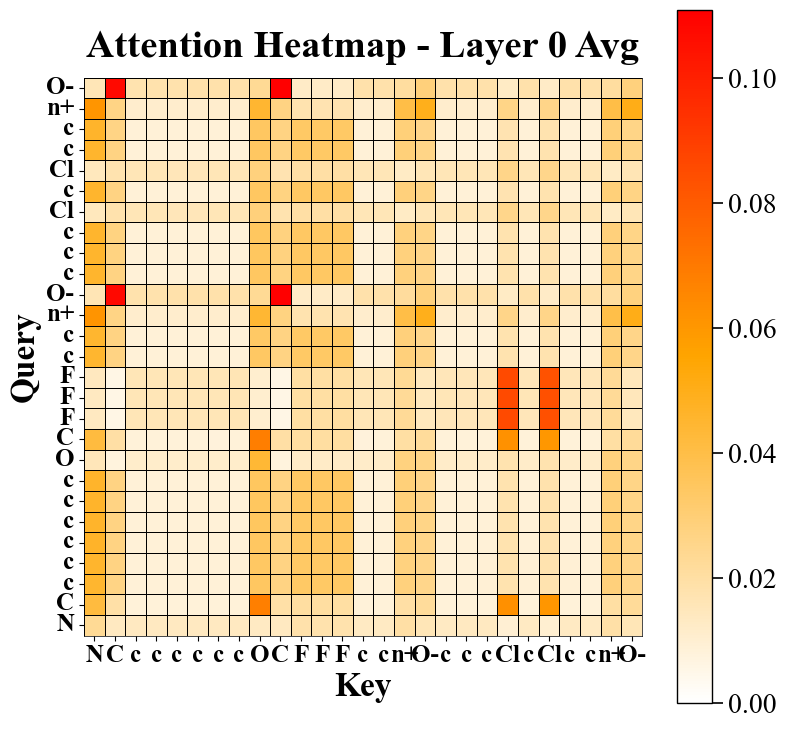

In [189]:
plt.figure(figsize=(9,9))

colors = ["white", "orange", "red"]
custom_cmap = LinearSegmentedColormap.from_list("white_orange_red", colors)

vmin_value = 0.0
vmax_value = 0.1109

ax = sns.heatmap(layer_0_avg_atom, 
                 xticklabels=chemical_atoms, 
                 yticklabels=chemical_atoms, 
                 cmap=custom_cmap, 
                 vmin=vmin_value, 
                 vmax=vmax_value, 
                 linewidths=0.5, 
                 linecolor='black', 
                 square=True 
                )

plt.xlabel("Key", fontsize=24, fontweight='bold')
plt.ylabel("Query", fontsize=24, fontweight='bold')

plt.title("Attention Heatmap - Layer 0 Avg", fontsize=28, pad=15, fontweight='bold')
plt.xticks(rotation=0,fontsize=18, weight='bold')
plt.yticks(rotation=0,fontsize=18, weight='bold')

ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)      
    spine.set_color('black')    

cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)       
cbar.outline.set_linewidth(1.0)    
cbar.outline.set_edgecolor('black')  

major_ticks = [0.00, 0.02, 0.04, 0.06, 0.08,0.10]
cbar.set_ticks(major_ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in major_ticks])

cbar.ax.tick_params(
    which='major',
    length=8,      
    width=1.2,     
    direction='out',
    color='black',
    labelsize=20 
)

plt.savefig(r"E:\Projects\Mycobacterium tuberculosis\07-Self-Attention Visualization on SMILES\layer_0_avg.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [64]:
attn_weights_1 = all_attn_weights[1].cpu()

In [65]:
attn_weights_1.shape

torch.Size([1, 8, 52, 52])

In [66]:
layer_1_head_0 = attn_weights_1[0, 0].numpy()  # head 0
print(layer_1_head_0)
print(len(layer_1_head_0))

[[1.03615115e-04 9.50260926e-07 6.53149300e-06 ... 6.62686489e-07
  4.44166988e-01 2.02428936e-07]
 [1.32409446e-02 2.89269574e-02 9.23963916e-03 ... 2.87806261e-02
  1.65859107e-02 2.27658786e-02]
 [2.12098490e-02 1.06734317e-02 2.72552446e-02 ... 7.32441479e-03
  1.30821019e-02 1.20002283e-02]
 ...
 [2.64343340e-02 1.73687260e-03 3.46375862e-03 ... 8.52282159e-03
  2.71665454e-01 3.88140697e-03]
 [8.64742137e-03 2.10952014e-03 5.46280434e-03 ... 8.25441163e-03
  1.20713077e-02 9.79014393e-03]
 [1.52494516e-02 7.74346432e-03 5.09955920e-03 ... 3.99786420e-03
  6.09242022e-02 2.74340156e-03]]
52


In [67]:
layer_1_head_0_atom = np.round(layer_1_head_0[np.ix_(atom_indices, atom_indices)],2)
print(layer_1_head_0_atom.shape)
print(len(layer_1_head_0_atom))
print(np.max(layer_1_head_0_atom))

(27, 27)
27
0.48


In [68]:
layer_1_head_1 = attn_weights_1[0, 1].numpy()  # head 0
print(layer_1_head_1)
print(len(layer_1_head_1))

[[0.00037372 0.00127105 0.00067524 ... 0.00022021 0.03029317 0.00034391]
 [0.01559481 0.01768952 0.08360897 ... 0.04032472 0.01476927 0.01394828]
 [0.01245994 0.02543558 0.00665096 ... 0.00079147 0.00434022 0.0148957 ]
 ...
 [0.03224337 0.00987597 0.00929849 ... 0.00754484 0.00602353 0.00595649]
 [0.00304163 0.03344326 0.00534774 ... 0.00537083 0.00198994 0.01091043]
 [0.01392277 0.04504226 0.11651754 ... 0.0056736  0.02396093 0.01054388]]
52


In [69]:
layer_1_head_1_atom = np.round(layer_1_head_1[np.ix_(atom_indices, atom_indices)],2)
print(layer_1_head_1_atom.shape)
print(len(layer_1_head_1_atom))
print(np.max(layer_1_head_1_atom))

(27, 27)
27
0.26


In [70]:
layer_1_head_2 = attn_weights_1[0, 2].numpy()  # head 0
print(layer_1_head_2)
print(len(layer_1_head_2))

[[2.29485566e-03 2.88637075e-05 9.51603234e-01 ... 2.24377334e-04
  1.75020397e-02 2.53740727e-04]
 [1.67137943e-02 1.11774094e-02 1.92599848e-01 ... 1.76251568e-02
  1.03364810e-01 7.10801780e-03]
 [1.80273200e-03 2.58257270e-01 6.06337962e-05 ... 1.98402405e-02
  2.19434616e-04 2.45070197e-02]
 ...
 [7.41147762e-03 2.39361189e-02 9.49686393e-03 ... 1.40882349e-02
  1.82678141e-02 8.33025295e-03]
 [4.48262366e-03 1.07476786e-04 2.15642035e-01 ... 8.89587449e-04
  1.35649905e-01 1.47908472e-03]
 [1.96748059e-02 3.98055743e-03 8.07176828e-01 ... 3.20772943e-03
  2.16294341e-02 4.97336779e-03]]
52


In [71]:
layer_1_head_2_atom = np.round(layer_1_head_2[np.ix_(atom_indices, atom_indices)],2)
print(layer_1_head_2_atom.shape)
print(len(layer_1_head_2_atom))
print(np.max(layer_1_head_2_atom))

(27, 27)
27
0.81


In [72]:
layer_1_head_3 = attn_weights_1[0, 3].numpy()  # head 0
print(layer_1_head_3)
print(len(layer_1_head_3))

[[0.00633498 0.00226608 0.02175682 ... 0.00043715 0.00229994 0.01002555]
 [0.03216657 0.01554723 0.04975196 ... 0.00660727 0.02359618 0.01053628]
 [0.05583866 0.00545332 0.1035795  ... 0.03284461 0.07317544 0.01272253]
 ...
 [0.03457658 0.02098754 0.03505701 ... 0.00822607 0.02296002 0.02032506]
 [0.04206765 0.00582063 0.00798766 ... 0.01546564 0.15750529 0.00753143]
 [0.02310597 0.00948882 0.0755067  ... 0.00631737 0.01139214 0.01360628]]
52


In [73]:
layer_1_head_3_atom = np.round(layer_1_head_3[np.ix_(atom_indices, atom_indices)],2)
print(layer_1_head_3_atom.shape)
print(len(layer_1_head_3_atom))
print(np.max(layer_1_head_3_atom))

(27, 27)
27
0.16


In [74]:
layer_1_head_4 = attn_weights_1[0, 4].numpy()  # head 0
print(layer_1_head_4)
print(len(layer_1_head_4))

[[0.03439313 0.00338281 0.00839102 ... 0.01430512 0.04748131 0.0128906 ]
 [0.01349255 0.1022682  0.00491364 ... 0.0122214  0.00492836 0.02540886]
 [0.01294298 0.03785191 0.33462194 ... 0.04925723 0.02065379 0.00630208]
 ...
 [0.00692959 0.04483891 0.0361062  ... 0.00944903 0.02713216 0.07782257]
 [0.02042757 0.01727062 0.03760701 ... 0.02321631 0.01373716 0.04091286]
 [0.01616375 0.01694572 0.01777466 ... 0.03371045 0.10121983 0.02007799]]
52


In [75]:
layer_1_head_4_atom = np.round(layer_1_head_4[np.ix_(atom_indices, atom_indices)],2)
print(layer_1_head_4_atom.shape)
print(len(layer_1_head_4_atom))
print(np.max(layer_1_head_4_atom))

(27, 27)
27
0.33


In [76]:
layer_1_head_5 = attn_weights_1[0, 5].numpy()  # head 0
print(layer_1_head_5)
print(len(layer_1_head_5))

[[2.21876544e-03 5.20269969e-04 4.16547933e-04 ... 6.79363206e-04
  1.93766190e-03 5.33575512e-05]
 [1.30514633e-02 1.57619715e-02 4.72411793e-03 ... 6.24624267e-03
  1.38859944e-02 1.46687984e-01]
 [1.15884896e-02 7.58603355e-03 4.15345728e-01 ... 2.62977239e-02
  2.11901162e-02 4.77557145e-02]
 ...
 [1.50048537e-02 1.74624100e-02 4.94156554e-02 ... 1.27025163e-02
  4.85605784e-02 6.16156012e-02]
 [7.47959130e-03 9.51687898e-03 1.01575285e-01 ... 4.88336869e-02
  1.59787819e-01 7.46058812e-03]
 [3.59915458e-02 1.27244471e-02 4.21042927e-02 ... 1.25052314e-02
  2.49722246e-02 4.22244258e-02]]
52


In [77]:
layer_1_head_5_atom = np.round(layer_1_head_5[np.ix_(atom_indices, atom_indices)],2)
print(layer_1_head_5_atom.shape)
print(len(layer_1_head_5_atom))
print(np.max(layer_1_head_5_atom))

(27, 27)
27
0.5


In [78]:
layer_1_head_6 = attn_weights_1[0, 6].numpy()  # head 0
print(layer_1_head_6)
print(len(layer_1_head_6))

[[0.01637091 0.01716765 0.01473976 ... 0.00617562 0.02614915 0.00839376]
 [0.01316983 0.01610767 0.00281804 ... 0.01255706 0.00907041 0.01070399]
 [0.00585186 0.02576418 0.06188664 ... 0.00399177 0.00705425 0.01134017]
 ...
 [0.01332351 0.01544576 0.01574051 ... 0.01010213 0.01062215 0.00708556]
 [0.01933347 0.00695344 0.01117466 ... 0.00588639 0.01855447 0.01761182]
 [0.01045372 0.02349588 0.01367337 ... 0.01547232 0.01841816 0.01127485]]
52


In [79]:
layer_1_head_6_atom = np.round(layer_1_head_6[np.ix_(atom_indices, atom_indices)],2)
print(layer_1_head_6_atom.shape)
print(len(layer_1_head_6_atom))
print(np.max(layer_1_head_6_atom))

(27, 27)
27
0.32


In [80]:
layer_1_head_7 = attn_weights_1[0, 7].numpy()  # head 0
print(layer_1_head_7)
print(len(layer_1_head_7))

[[2.0288355e-03 1.1477914e-03 5.0320709e-04 ... 3.4105757e-05
  2.1824604e-04 8.7876228e-04]
 [1.2600940e-02 1.5136923e-02 6.2358774e-02 ... 1.9744037e-02
  2.7841184e-02 1.4771959e-02]
 [1.3864906e-02 8.7289354e-03 1.0199757e-02 ... 2.8257899e-03
  8.2211038e-03 1.0172657e-02]
 ...
 [1.0290204e-02 4.5177296e-02 6.3808441e-02 ... 3.3636816e-02
  9.6253147e-03 2.4828535e-02]
 [1.7206935e-02 3.8523231e-02 1.8893491e-02 ... 9.2020482e-03
  2.1700157e-02 1.9217357e-02]
 [1.8667120e-02 4.2264913e-03 2.6883099e-02 ... 5.8686328e-03
  1.9747779e-02 1.8457266e-02]]
52


In [81]:
layer_1_head_7_atom = np.round(layer_1_head_7[np.ix_(atom_indices, atom_indices)],2)
print(layer_1_head_7_atom.shape)
print(len(layer_1_head_7_atom))
print(np.max(layer_1_head_7_atom))

(27, 27)
27
0.14


In [82]:
layer_1_avg = attn_weights_1.mean(dim=1).numpy().squeeze(0)
print(layer_1_avg)
print(layer_1_avg.shape)

[[0.00801485 0.00322318 0.12476154 ... 0.00275958 0.07125607 0.00410499]
 [0.01625386 0.02782699 0.05125187 ... 0.01801331 0.02675527 0.03149141]
 [0.01694493 0.04746883 0.11995006 ... 0.01789666 0.01849206 0.01746201]
 ...
 [0.01827674 0.02243261 0.02779837 ... 0.01303406 0.05185713 0.02623069]
 [0.01533586 0.01421813 0.05046133 ... 0.01463986 0.06512451 0.01436421]
 [0.01915364 0.01545595 0.13809201 ... 0.01084415 0.03528308 0.01548768]]
(52, 52)


In [84]:
#layer_1_avg_atom = np.round(layer_1_avg[np.ix_(atom_indices, atom_indices)],2)
layer_1_avg_atom = layer_1_avg[np.ix_(atom_indices, atom_indices)]
print(layer_1_avg_atom.shape)
print(len(layer_1_avg_atom))
print(np.max(layer_1_avg_atom))

(27, 27)
27
0.119950056


In [85]:
layer_1_avg_df = pd.DataFrame(layer_1_avg_atom, index=chemical_atoms, columns=chemical_atoms)
layer_1_avg_df

,N,C,c,c,c,c,c,c,O,C,...,c,c,c,Cl,c,Cl,c,c,n+,O-
N,0.119950,0.017643,0.016599,0.016415,0.016508,0.016571,0.016517,0.016446,0.012370,0.017512,...,0.016095,0.016347,0.016388,0.014606,0.016285,0.014580,0.016279,0.016252,0.060045,0.018492
C,0.110916,0.008264,0.005931,0.005925,0.005886,0.005823,0.005828,0.005859,0.045220,0.008307,...,0.005855,0.005921,0.005948,0.053091,0.005875,0.052318,0.005884,0.005873,0.046670,0.053956
c,0.013097,0.017544,0.012017,0.012086,0.012042,0.012039,0.012075,0.012106,0.060462,0.017627,...,0.012053,0.012059,0.012072,0.018546,0.012141,0.018715,0.012120,0.012036,0.015013,0.021453
c,0.013296,0.017706,0.012112,0.012180,0.012136,0.012133,0.012170,0.012202,0.060311,0.017788,...,0.012146,0.012153,0.012166,0.018390,0.012233,0.018558,0.012212,0.012129,0.014714,0.021122
c,0.013183,0.017781,0.012040,0.012108,0.012066,0.012064,0.012102,0.012132,0.061797,0.017864,...,0.012076,0.012084,0.012098,0.018456,0.012168,0.018620,0.012145,0.012062,0.014729,0.021235
c,0.013073,0.017457,0.011946,0.012015,0.011971,0.011971,0.012008,0.012037,0.062447,0.017534,...,0.011982,0.011989,0.012003,0.018654,0.012073,0.018816,0.012049,0.011966,0.015161,0.022018
c,0.013073,0.017352,0.011947,0.012015,0.011970,0.011970,0.012007,0.012036,0.062214,0.017428,...,0.011979,0.011986,0.012000,0.018709,0.012070,0.018871,0.012046,0.011963,0.015241,0.022089
c,0.013068,0.017367,0.011987,0.012055,0.012009,0.012008,0.012046,0.012076,0.061775,0.017443,...,0.012016,0.012022,0.012036,0.018662,0.012107,0.018825,0.012084,0.012000,0.015186,0.021882
O,0.022274,0.010948,0.008588,0.008689,0.008703,0.008573,0.008544,0.008567,0.054673,0.011052,...,0.008865,0.008906,0.008902,0.042021,0.008745,0.040848,0.008893,0.008960,0.015625,0.026701
C,0.110817,0.008421,0.006055,0.006048,0.006008,0.005945,0.005949,0.005980,0.045872,0.008457,...,0.005974,0.006041,0.006069,0.052012,0.005996,0.051230,0.006006,0.005996,0.046506,0.053024


In [86]:
layer_1_avg_df.to_csv('layer_1_avg_weights.csv', index=True)

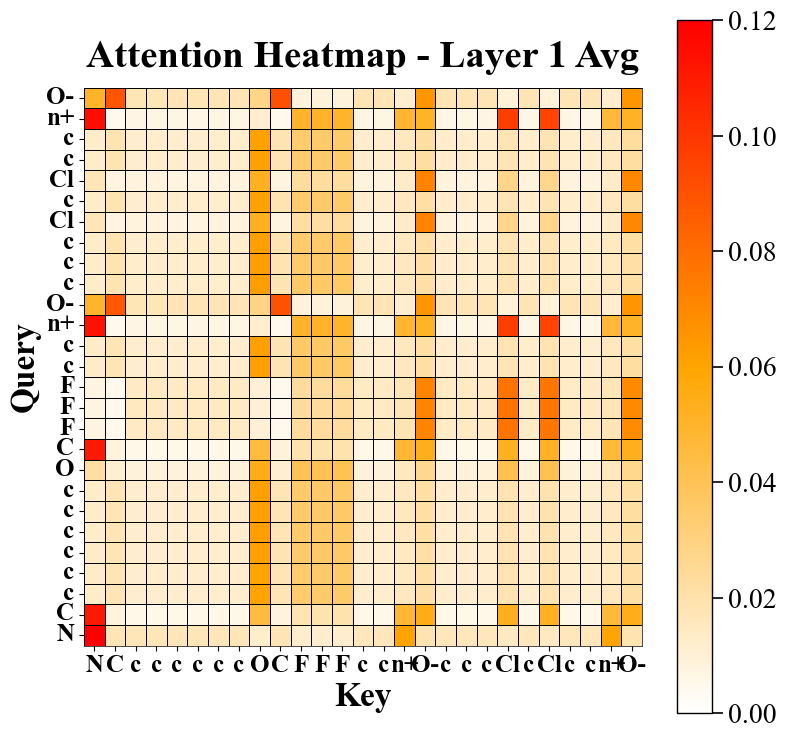

In [188]:
plt.figure(figsize=(9,9))

colors = ["white", "orange", "red"]
custom_cmap = LinearSegmentedColormap.from_list("white_orange_red", colors)

vmin_value = 0.0
vmax_value = 0.1199   

ax = sns.heatmap(layer_1_avg_atom, 
                 xticklabels=chemical_atoms, 
                 yticklabels=chemical_atoms, 
                 cmap=custom_cmap, 
                 vmin=vmin_value, 
                 vmax=vmax_value, 
                 linewidths=0.5, 
                 linecolor='black', 
                 square=True 
                ) 

plt.xlabel("Key", fontsize=24, fontweight='bold')
plt.ylabel("Query", fontsize=24, fontweight='bold')

plt.title("Attention Heatmap - Layer 1 Avg", fontsize=28, pad=15, fontweight='bold')
plt.xticks(rotation=0,fontsize=18, weight='bold')
plt.yticks(rotation=0,fontsize=18, weight='bold')

ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)      
    spine.set_color('black')    

cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)       
cbar.outline.set_linewidth(1.0)      
cbar.outline.set_edgecolor('black')  

#major_ticks = [0.00, 0.10, 0.20, 0.30, 0.40]
major_ticks = [0.00, 0.02, 0.04, 0.06, 0.08,0.10,0.12]
cbar.set_ticks(major_ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in major_ticks])

cbar.ax.tick_params(
    which='major',
    length=8,      
    width=1.2,     
    direction='out',
    color='black',
    labelsize=20 
)

plt.savefig(r"E:\Projects\Mycobacterium tuberculosis\07-Self-Attention Visualization on SMILES\layer_1_avg.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [94]:
attn_weights_2 = all_attn_weights[2].cpu()

In [95]:
attn_weights_2.shape

torch.Size([1, 8, 52, 52])

In [96]:
layer_2_head_0 = attn_weights_2[0, 0].numpy()  # head 0
print(layer_2_head_0)
print(len(layer_2_head_0))

[[3.4796823e-05 8.3633876e-07 1.1825724e-06 ... 7.9037954e-07
  4.8820311e-01 7.1247848e-07]
 [5.5161393e-03 2.2672501e-03 1.1611109e-03 ... 1.4378550e-03
  3.2970983e-01 2.0773555e-03]
 [9.2675835e-03 1.9588061e-02 6.3191750e-03 ... 5.7610241e-03
  4.8438883e-03 8.9166248e-03]
 ...
 [2.1088300e-02 3.1543290e-03 3.3817426e-03 ... 4.1526305e-03
  1.3353245e-01 3.3019418e-03]
 [1.0105032e-02 7.4116876e-03 6.6685998e-03 ... 2.9347638e-02
  6.0520996e-03 2.2334319e-02]
 [3.7728478e-03 1.8083375e-03 8.4055547e-04 ... 7.4524031e-04
  4.4564721e-01 7.1678672e-04]]
52


In [97]:
layer_2_head_0_atom = np.round(layer_2_head_0[np.ix_(atom_indices, atom_indices)],2)
print(layer_2_head_0_atom.shape)
print(len(layer_2_head_0_atom))
print(np.max(layer_2_head_0_atom))

(27, 27)
27
0.51


In [98]:
layer_2_head_1 = attn_weights_2[0, 1].numpy()  # head 0
print(layer_2_head_1)
print(len(layer_2_head_1))

[[2.7964279e-04 1.1799969e-01 2.6969932e-04 ... 7.0603448e-03
  3.8859464e-05 2.8885631e-03]
 [9.1291489e-03 1.5820578e-02 5.4169986e-03 ... 3.0215763e-02
  5.3111236e-03 1.0797460e-02]
 [8.6538470e-04 1.4328462e-01 2.3035139e-03 ... 6.6349879e-03
  2.8330554e-05 1.1726890e-02]
 ...
 [6.2157018e-03 9.5063746e-03 6.0903688e-04 ... 1.9732795e-03
  5.5514683e-04 9.3708426e-04]
 [4.3501335e-04 2.5357252e-02 1.8730006e-03 ... 1.5676065e-03
  1.7439957e-04 1.4747088e-03]
 [2.0056530e-03 8.7838471e-02 1.3806057e-03 ... 9.1712642e-03
  5.2564777e-04 4.7878167e-03]]
52


In [99]:
layer_2_head_1_atom = np.round(layer_2_head_1[np.ix_(atom_indices, atom_indices)],2)
print(layer_2_head_1_atom.shape)
print(len(layer_2_head_1_atom))
print(np.max(layer_2_head_1_atom))

(27, 27)
27
0.2


In [100]:
layer_2_head_2 = attn_weights_2[0, 2].numpy()  # head 0
print(layer_2_head_2)
print(len(layer_2_head_2))

[[1.22497445e-02 3.65471793e-03 1.31142974e-01 ... 7.57539319e-03
  3.56614701e-02 1.58781558e-02]
 [1.09535374e-03 8.72436722e-05 5.16718864e-01 ... 4.62491880e-04
  2.30521426e-01 5.84512367e-04]
 [2.32471265e-02 5.77948522e-03 1.19060382e-01 ... 2.35837419e-02
  4.45274003e-02 2.12845169e-02]
 ...
 [9.48264438e-04 1.63807890e-05 6.45160615e-01 ... 9.54444404e-05
  1.76964700e-01 1.86578021e-04]
 [1.14526292e-02 2.73908354e-05 1.17253006e-01 ... 3.32976953e-04
  2.94761777e-01 1.15073367e-03]
 [1.22024948e-02 2.84952950e-03 3.53311956e-01 ... 4.62614466e-03
  1.04330085e-01 1.22959074e-02]]
52


In [101]:
layer_2_head_2_atom = np.round(layer_2_head_2[np.ix_(atom_indices, atom_indices)],2)
print(layer_2_head_2_atom.shape)
print(len(layer_2_head_2_atom))
print(np.max(layer_2_head_2_atom))

(27, 27)
27
0.51


In [102]:
layer_2_head_3 = attn_weights_2[0, 3].numpy()  # head 0
print(layer_2_head_3)
print(len(layer_2_head_3))

[[1.3344904e-02 6.4610406e-03 1.1484881e-02 ... 2.2549804e-03
  5.1304705e-02 9.0947095e-03]
 [2.0079805e-02 3.9079050e-03 1.1747040e-02 ... 1.5344247e-03
  7.5902067e-02 7.3216073e-03]
 [5.9115472e-03 3.9044760e-05 6.6403538e-02 ... 4.6184490e-04
  4.4715461e-01 3.6871404e-04]
 ...
 [2.0602595e-02 4.4487296e-03 3.5797197e-02 ... 1.4398447e-03
  1.9076474e-01 9.9736685e-03]
 [2.3139292e-02 6.4254724e-03 3.8563259e-02 ... 8.4749022e-03
  1.4298382e-01 9.1863507e-03]
 [1.5989007e-02 2.9960503e-03 1.3776233e-02 ... 2.6243713e-03
  1.0616238e-01 6.1283796e-03]]
52


In [103]:
layer_2_head_3_atom = np.round(layer_2_head_3[np.ix_(atom_indices, atom_indices)],2)
print(layer_2_head_3_atom.shape)
print(len(layer_2_head_3_atom))
print(np.max(layer_2_head_3_atom))

(27, 27)
27
0.45


In [104]:
layer_2_head_4 = attn_weights_2[0, 4].numpy()  # head 0
print(layer_2_head_4)
print(len(layer_2_head_4))

[[0.01889266 0.00822967 0.00146205 ... 0.00872747 0.0505301  0.01670686]
 [0.03723017 0.03272868 0.0024427  ... 0.00677347 0.01358739 0.01581549]
 [0.02718728 0.02336649 0.03940846 ... 0.03896764 0.1605027  0.01378099]
 ...
 [0.02601687 0.02039221 0.00339223 ... 0.00577254 0.00275964 0.01884368]
 [0.01879909 0.01887251 0.01150868 ... 0.02791224 0.01521804 0.02586933]
 [0.03722108 0.00863505 0.00279901 ... 0.005864   0.10374302 0.00824096]]
52


In [105]:
layer_2_head_4_atom = np.round(layer_2_head_4[np.ix_(atom_indices, atom_indices)],2)
print(layer_2_head_4_atom.shape)
print(len(layer_2_head_4_atom))
print(np.max(layer_2_head_4_atom))

(27, 27)
27
0.24


In [106]:
layer_2_head_5 = attn_weights_2[0, 5].numpy()  # head 0
print(layer_2_head_5)
print(len(layer_2_head_5))

[[0.01304628 0.0023988  0.41497847 ... 0.00255935 0.07347018 0.00171431]
 [0.01230922 0.06744532 0.01283589 ... 0.02524395 0.01070846 0.11789133]
 [0.01361119 0.00756665 0.19647495 ... 0.02037862 0.00966412 0.03512025]
 ...
 [0.01461933 0.0205059  0.07729067 ... 0.02461579 0.0744927  0.05196228]
 [0.01551894 0.0008503  0.08334727 ... 0.03239879 0.11423183 0.00225979]
 [0.02370846 0.01395933 0.15991043 ... 0.00920829 0.01312404 0.03972732]]
52


In [107]:
layer_2_head_5_atom = np.round(layer_2_head_5[np.ix_(atom_indices, atom_indices)],2)
print(layer_2_head_5_atom.shape)
print(len(layer_2_head_5_atom))
print(np.max(layer_2_head_5_atom))

(27, 27)
27
0.25


In [108]:
layer_2_head_6 = attn_weights_2[0, 6].numpy()  # head 0
print(layer_2_head_6)
print(len(layer_2_head_6))

[[0.03301473 0.02537985 0.02668782 ... 0.00667885 0.02612298 0.01556065]
 [0.00476618 0.01500422 0.01722129 ... 0.0175281  0.01246434 0.02132638]
 [0.00936553 0.03194285 0.4412857  ... 0.00343851 0.00541254 0.03014163]
 ...
 [0.01712274 0.02058422 0.028691   ... 0.00335211 0.02708334 0.01120689]
 [0.01869162 0.00538147 0.0015004  ... 0.00166348 0.00208247 0.00684584]
 [0.00883113 0.01746855 0.03740497 ... 0.01002404 0.01629937 0.02230511]]
52


In [109]:
layer_2_head_6_atom = np.round(layer_2_head_6[np.ix_(atom_indices, atom_indices)],2)
print(layer_2_head_6_atom.shape)
print(len(layer_2_head_6_atom))
print(np.max(layer_2_head_6_atom))

(27, 27)
27
0.63


In [110]:
layer_2_head_7 = attn_weights_2[0, 7].numpy()  # head 0
print(layer_2_head_7)
print(len(layer_2_head_7))

[[6.4649369e-04 8.2649335e-02 9.9441828e-03 ... 1.0466433e-02
  6.9433467e-05 1.0638295e-02]
 [1.0528399e-02 1.5161456e-02 5.2705333e-02 ... 6.3377195e-03
  9.5634814e-03 1.1380974e-02]
 [1.3385984e-02 3.7058133e-03 1.4559995e-02 ... 1.3140679e-03
  1.5596049e-02 4.6252888e-03]
 ...
 [8.6602485e-03 2.0501683e-02 7.5056753e-03 ... 9.0807490e-03
  4.2130686e-03 8.8878730e-03]
 [1.3823940e-03 3.1040024e-02 1.9982990e-02 ... 2.0531222e-02
  2.1235868e-03 2.4212576e-02]
 [2.7550177e-03 2.2301273e-03 3.5358584e-03 ... 7.1198912e-04
  2.0875058e-03 1.4718974e-03]]
52


In [111]:
layer_2_head_7_atom = np.round(layer_2_head_3[np.ix_(atom_indices, atom_indices)],2)
print(layer_2_head_7_atom.shape)
print(len(layer_2_head_7_atom))
print(np.max(layer_2_head_7_atom))

(27, 27)
27
0.45


In [112]:
layer_2_avg = attn_weights_2.mean(dim=1).numpy().squeeze(0)
print(layer_2_avg)
print(layer_2_avg.shape)

[[0.01143866 0.03084674 0.07449641 ... 0.00566545 0.0906751  0.00906028]
 [0.0125818  0.01905283 0.07753115 ... 0.01119172 0.08597102 0.02339939]
 [0.0128552  0.02940912 0.11072697 ... 0.01256755 0.0859662  0.01574561]
 ...
 [0.01440926 0.01238873 0.10022851 ... 0.0063103  0.07629573 0.0131625 ]
 [0.0124405  0.01192076 0.03508715 ... 0.01527861 0.07220351 0.01166671]
 [0.01331071 0.01722318 0.07161995 ... 0.00537192 0.0989899  0.01195927]]
(52, 52)


In [114]:
layer_2_avg_atom = layer_2_avg[np.ix_(atom_indices, atom_indices)]
print(layer_2_avg_atom.shape)
print(len(layer_2_avg_atom))
print(np.max(layer_2_avg_atom))

(27, 27)
27
0.13253711


In [115]:
layer_2_avg_df = pd.DataFrame(layer_2_avg_atom, index=chemical_atoms, columns=chemical_atoms)
layer_2_avg_df
layer_2_avg_df.to_csv('layer_2_avg_weights.csv', index=True)

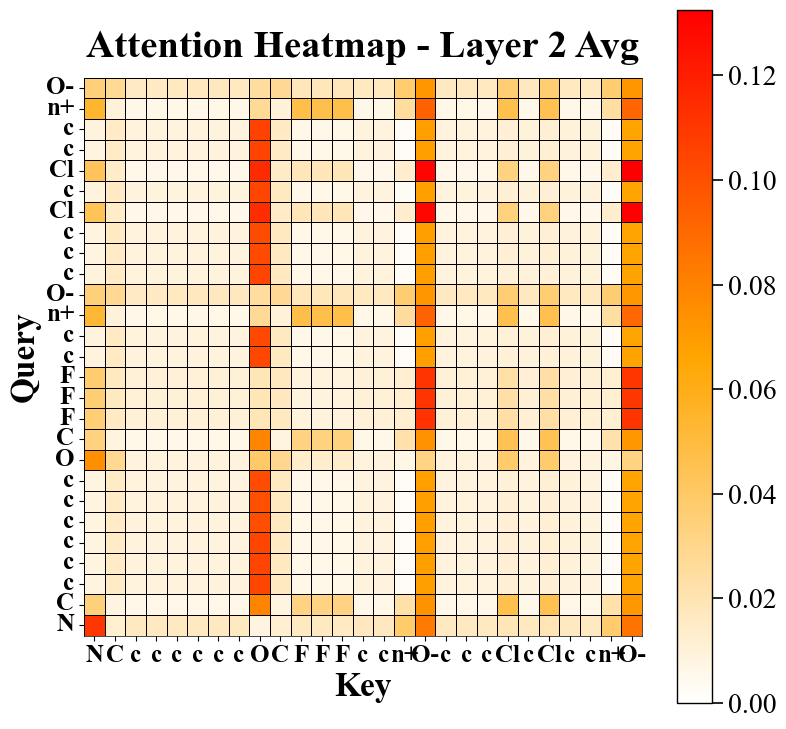

In [187]:
plt.figure(figsize=(9,9))

colors = ["white", "orange", "red"]
custom_cmap = LinearSegmentedColormap.from_list("white_orange_red", colors)

vmin_value = 0.0   
vmax_value = 0.1325   

ax = sns.heatmap(layer_2_avg_atom, 
                 xticklabels=chemical_atoms, 
                 yticklabels=chemical_atoms, 
                 cmap=custom_cmap, 
                 vmin=vmin_value, 
                 vmax=vmax_value, 
                 linewidths=0.5, 
                 linecolor='black', 
                 square=True 
                ) 

plt.xlabel("Key", fontsize=24, fontweight='bold')
plt.ylabel("Query", fontsize=24, fontweight='bold')

plt.title("Attention Heatmap - Layer 2 Avg", fontsize=28, pad=15, fontweight='bold')
plt.xticks(rotation=0,fontsize=18, weight='bold')
plt.yticks(rotation=0,fontsize=18, weight='bold')

ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)      
    spine.set_color('black')    

cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)       
cbar.outline.set_linewidth(1.0)      
cbar.outline.set_edgecolor('black')  

major_ticks = [0.00, 0.02, 0.04, 0.06, 0.08,0.10,0.12]
cbar.set_ticks(major_ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in major_ticks])

cbar.ax.tick_params(
    which='major',
    length=8,      
    width=1.2,     
    direction='out',
    color='black',
    labelsize=20 
)

plt.savefig(r"E:\Projects\Mycobacterium tuberculosis\07-Self-Attention Visualization on SMILES\layer_2_avg.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [119]:
attn_weights_3 = all_attn_weights[3].cpu() 

In [120]:
attn_weights_3.shape

torch.Size([1, 8, 52, 52])

In [121]:
layer_3_head_0 = attn_weights_3[0, 0].numpy()  # head 0
print(layer_3_head_0)
print(len(layer_3_head_0))

[[1.1636736e-06 2.5856635e-09 4.9406037e-08 ... 7.8151876e-09
  4.8767966e-01 2.4917644e-09]
 [2.7166222e-06 7.9655864e-09 2.3688189e-07 ... 1.3607076e-08
  4.9667576e-01 7.1008235e-09]
 [2.5098911e-03 2.4307726e-02 8.7110596e-03 ... 3.0753168e-03
  5.1737260e-03 9.2767095e-03]
 ...
 [1.3440056e-03 5.2212640e-06 1.1574952e-04 ... 1.9375331e-05
  4.9523002e-01 1.4167484e-05]
 [4.4002496e-03 3.4773874e-03 4.8613260e-04 ... 9.9423891e-03
  8.9570158e-04 5.5172155e-03]
 [2.0666441e-05 1.2527086e-07 2.2764248e-06 ... 1.6657324e-07
  4.9375686e-01 8.7789488e-08]]
52


In [122]:
layer_3_head_0_atom = np.round(layer_3_head_0[np.ix_(atom_indices, atom_indices)],2)
print(layer_3_head_0_atom.shape)
print(len(layer_3_head_0_atom))
print(np.max(layer_3_head_0_atom))

(27, 27)
27
0.51


In [123]:
layer_3_head_1 = attn_weights_3[0, 1].numpy()  # head 0
print(layer_3_head_1)
print(len(layer_3_head_1))

[[1.9511568e-03 5.9203375e-03 3.9000419e-04 ... 7.9859828e-04
  4.0980591e-03 5.3730543e-04]
 [1.4010091e-02 1.6990678e-02 3.6236621e-03 ... 5.7562436e-03
  1.5069563e-04 5.5209151e-03]
 [7.2547277e-03 2.7839867e-02 1.4341175e-02 ... 4.6451692e-03
  2.8883356e-03 1.2682733e-02]
 ...
 [6.0392232e-03 6.0568196e-03 4.5606258e-04 ... 1.0337456e-03
  2.7920276e-05 5.0051475e-04]
 [3.6318754e-03 2.2950361e-02 3.5306802e-03 ... 7.8960741e-03
  1.0803016e-03 3.7578403e-03]
 [4.3949070e-03 1.2065623e-02 1.8309650e-03 ... 1.7540248e-03
  2.3887039e-03 1.3991415e-03]]
52


In [124]:
layer_3_head_1_atom = np.round(layer_3_head_1[np.ix_(atom_indices, atom_indices)],2)
print(layer_3_head_1_atom.shape)
print(len(layer_3_head_1_atom))
print(np.max(layer_3_head_1_atom))

(27, 27)
27
0.38


In [125]:
layer_3_head_2 = attn_weights_3[0, 2].numpy()  # head 0
print(layer_3_head_2)
print(len(layer_3_head_2))

[[1.30683742e-03 3.45110297e-02 4.54115390e-04 ... 9.85321868e-03
  3.06523405e-04 2.09653471e-02]
 [4.17634938e-03 9.11862357e-04 4.00998354e-01 ... 1.99757190e-03
  9.89206731e-02 8.63934588e-03]
 [1.08663449e-02 2.58233957e-02 3.20887845e-03 ... 3.11918072e-02
  1.24356765e-02 2.53027417e-02]
 ...
 [2.69116671e-03 1.45074140e-04 5.74491501e-01 ... 3.34667537e-04
  1.70015693e-01 1.53743417e-03]
 [5.52076614e-03 1.03479754e-02 2.98995641e-04 ... 1.40409321e-02
  1.76729052e-03 1.11566195e-02]
 [4.64842748e-03 1.92344114e-02 1.57671515e-02 ... 1.88710578e-02
  5.26872789e-03 3.63523737e-02]]
52


In [126]:
layer_3_head_2_atom = np.round(layer_3_head_2[np.ix_(atom_indices, atom_indices)],2)
print(layer_3_head_2_atom.shape)
print(len(layer_3_head_2_atom))
print(np.max(layer_3_head_2_atom))

(27, 27)
27
0.84


In [127]:
layer_3_head_3 = attn_weights_3[0, 3].numpy()  # head 0
print(layer_3_head_3)
print(len(layer_3_head_3))

[[2.2099268e-02 2.1707008e-03 1.0324855e-02 ... 1.1849161e-03
  6.7723341e-02 4.4271778e-03]
 [2.0906124e-02 4.1613900e-03 4.6912380e-02 ... 2.9420401e-03
  1.3406096e-01 6.8977382e-03]
 [7.9233823e-03 8.9619039e-05 6.6533320e-02 ... 2.8560011e-04
  4.2965630e-01 8.0352771e-04]
 ...
 [1.5375207e-02 5.8593079e-03 7.6720729e-02 ... 2.8609831e-03
  2.6538464e-01 7.1329759e-03]
 [3.0400109e-02 2.5764583e-03 6.8976983e-02 ... 7.4963304e-03
  3.2789734e-01 7.2413171e-03]
 [1.7439524e-02 4.8531811e-03 1.6749239e-02 ... 3.6013210e-03
  8.4606878e-02 6.4851912e-03]]
52


In [128]:
layer_3_head_3_atom = np.round(layer_3_head_3[np.ix_(atom_indices, atom_indices)],2)
print(layer_3_head_3_atom.shape)
print(len(layer_3_head_3_atom))
print(np.max(layer_3_head_3_atom))

(27, 27)
27
0.44


In [129]:
layer_3_head_4 = attn_weights_3[0, 4].numpy()  # head 0
print(layer_3_head_4)
print(len(layer_3_head_4))

[[0.00319077 0.01775652 0.01325467 ... 0.03650087 0.0155714  0.1018126 ]
 [0.01902298 0.02402722 0.0113049  ... 0.01072074 0.10241029 0.01235832]
 [0.01312112 0.02530783 0.0176113  ... 0.04253621 0.06017181 0.03667377]
 ...
 [0.02959484 0.0117023  0.01712659 ... 0.00795299 0.06899285 0.01174781]
 [0.00276694 0.02031734 0.02778383 ... 0.0544273  0.00702783 0.13512212]
 [0.02446679 0.00639747 0.00222758 ... 0.00429126 0.1844774  0.00292983]]
52


In [130]:
layer_3_head_4_atom = np.round(layer_3_head_4[np.ix_(atom_indices, atom_indices)],2)
print(layer_3_head_4_atom.shape)
print(len(layer_3_head_4_atom))
print(np.max(layer_3_head_4_atom))

(27, 27)
27
0.33


In [131]:
layer_3_head_5 = attn_weights_3[0, 5].numpy()  # head 0
print(layer_3_head_5)
print(len(layer_3_head_5))

[[0.01871957 0.02200469 0.04748186 ... 0.01183494 0.00701815 0.01883569]
 [0.00884177 0.03319236 0.01507658 ... 0.02545468 0.00313623 0.12197676]
 [0.00651772 0.01497756 0.01483182 ... 0.03332035 0.00064483 0.03789989]
 ...
 [0.01185591 0.01793251 0.06426071 ... 0.03177205 0.05229901 0.08126487]
 [0.01091064 0.00871118 0.02935668 ... 0.05564627 0.06555185 0.00971361]
 [0.01141364 0.01988092 0.04078677 ... 0.0148133  0.00279886 0.07104057]]
52


In [132]:
layer_3_head_5_atom = np.round(layer_3_head_5[np.ix_(atom_indices, atom_indices)],2)
print(layer_3_head_5_atom.shape)
print(len(layer_3_head_5_atom))
print(np.max(layer_3_head_5_atom))

(27, 27)
27
0.1


In [133]:
layer_3_head_6 = attn_weights_3[0, 6].numpy()  # head 0
print(layer_3_head_6)
print(len(layer_3_head_6))

[[0.00557671 0.00034552 0.00162849 ... 0.00014934 0.02014129 0.00015412]
 [0.0098921  0.00586915 0.02037214 ... 0.00401354 0.03849239 0.00391154]
 [0.06158665 0.00804636 0.01915782 ... 0.00257427 0.01109076 0.00792799]
 ...
 [0.00785122 0.00430788 0.02177321 ... 0.00228673 0.02509889 0.00312692]
 [0.06021362 0.00568574 0.02536992 ... 0.00799797 0.00188208 0.0229585 ]
 [0.01291847 0.00663008 0.02372282 ... 0.00435758 0.04820472 0.00371271]]
52


In [134]:
layer_3_head_6_atom = np.round(layer_3_head_6[np.ix_(atom_indices, atom_indices)],2)
print(layer_3_head_6_atom.shape)
print(len(layer_3_head_6_atom))
print(np.max(layer_3_head_6_atom))

(27, 27)
27
0.17


In [135]:
layer_3_head_7 = attn_weights_3[0, 7].numpy()  # head 0
print(layer_3_head_7)
print(len(layer_3_head_7))

[[6.03207911e-04 6.64163828e-02 4.39307466e-03 ... 1.19066397e-02
  4.05537197e-04 6.05560886e-03]
 [1.10739935e-02 1.07668526e-02 1.95735469e-02 ... 1.38037307e-02
  1.50261551e-01 1.18987681e-02]
 [3.48260230e-03 3.96118592e-03 2.58295611e-03 ... 1.02226168e-03
  1.30075421e-02 1.21402717e-03]
 ...
 [1.50721539e-02 1.13829765e-02 5.68701420e-03 ... 1.21642295e-02
  3.17823961e-02 6.22825045e-03]
 [9.60478646e-05 1.00096107e-01 5.93525358e-02 ... 1.60182416e-02
  1.11548077e-04 4.99362051e-02]
 [9.56481695e-03 9.81499790e-04 1.31349894e-03 ... 8.99326929e-04
  7.23269060e-02 1.05177972e-03]]
52


In [136]:
layer_3_head_7_atom = np.round(layer_3_head_7[np.ix_(atom_indices, atom_indices)],2)
print(layer_3_head_7_atom.shape)
print(len(layer_3_head_7_atom))
print(np.max(layer_3_head_7_atom))

(27, 27)
27
0.25


In [137]:
layer_3_avg = attn_weights_3.mean(dim=1).numpy().squeeze(0)
print(layer_3_avg)
print(layer_3_avg.shape)

[[0.00668109 0.01864065 0.00974089 ... 0.00902857 0.075368   0.01909848]
 [0.01099077 0.01198994 0.06473273 ... 0.00808607 0.12801357 0.02140042]
 [0.0141578  0.01629419 0.01837229 ... 0.01483137 0.06688362 0.01647267]
 ...
 [0.01122797 0.00717401 0.09507894 ... 0.0073031  0.13860394 0.01394412]
 [0.01474253 0.02177032 0.02689447 ... 0.02168319 0.05077674 0.03067543]
 [0.0106084  0.00875541 0.01280004 ... 0.0060735  0.11172864 0.01537146]]
(52, 52)


In [138]:
layer_3_avg_atom = layer_3_avg[np.ix_(atom_indices, atom_indices)]
print(layer_3_avg_atom.shape)
print(len(layer_3_avg_atom))
print(np.max(layer_3_avg_atom))

(27, 27)
27
0.13749276


In [140]:
layer_3_avg_df = pd.DataFrame(layer_3_avg_atom, index=chemical_atoms, columns=chemical_atoms)
layer_3_avg_df.to_csv('layer_3_avg_weights.csv', index=True)

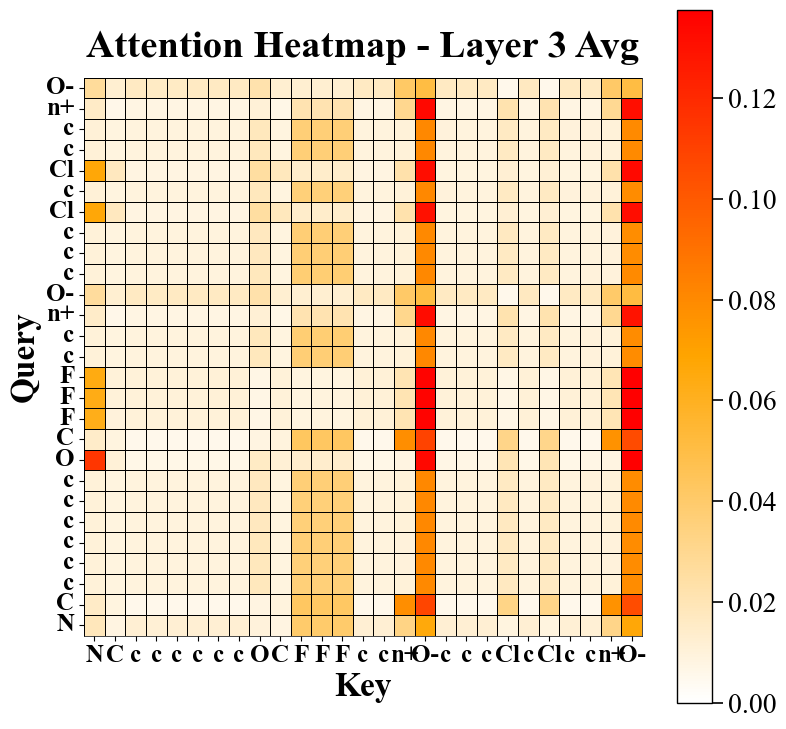

In [190]:
plt.figure(figsize=(9,9))

colors = ["white", "orange", "red"]
custom_cmap = LinearSegmentedColormap.from_list("white_orange_red", colors)

vmin_value = 0.0   
vmax_value = 0.1374   

ax = sns.heatmap(layer_3_avg_atom, 
                 xticklabels=chemical_atoms, 
                 yticklabels=chemical_atoms, 
                 cmap=custom_cmap, 
                 vmin=vmin_value, 
                 vmax=vmax_value, 
                 linewidths=0.5, 
                 linecolor='black', 
                 square=True 
                ) 

plt.xlabel("Key", fontsize=24, fontweight='bold')
plt.ylabel("Query", fontsize=24, fontweight='bold')

plt.title("Attention Heatmap - Layer 3 Avg", fontsize=28, pad=15, fontweight='bold')
plt.xticks(rotation=0,fontsize=18, weight='bold')
plt.yticks(rotation=0,fontsize=18, weight='bold')

ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)      
    spine.set_color('black')    

cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)       
cbar.outline.set_linewidth(1.0)      
cbar.outline.set_edgecolor('black')  

major_ticks = [0.00, 0.02, 0.04, 0.06, 0.08,0.10,0.12]
cbar.set_ticks(major_ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in major_ticks])
# 设置主刻度线样式
cbar.ax.tick_params(
    which='major',
    length=8,      
    width=1.2,     
    direction='out',
    color='black',
    labelsize=20 
)

plt.savefig(r"E:\Projects\Mycobacterium tuberculosis\07-Self-Attention Visualization on SMILES\layer_3_avg.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [143]:
attn_weights_4 = all_attn_weights[4].cpu() # 第3层的注意力 shape
attn_weights_4.shape

torch.Size([1, 8, 52, 52])

In [151]:
layer_4_head_0 = attn_weights_4[0, 0].numpy()  # head 0
print(layer_4_head_0)
print(len(layer_4_head_0))

[[3.29735735e-06 3.10939408e-09 6.61559909e-08 ... 4.86909926e-08
  4.86641943e-01 4.68492312e-09]
 [6.35263423e-05 1.06974596e-07 1.02537513e-06 ... 5.03430329e-07
  4.84703302e-01 1.14429945e-07]
 [1.44631870e-03 2.76619794e-05 1.17823409e-04 ... 3.79946541e-05
  4.66900617e-01 1.97902882e-05]
 ...
 [1.68537479e-02 8.15455714e-05 7.23758829e-04 ... 5.87138173e-04
  4.43518758e-01 2.36739274e-04]
 [1.13985091e-02 1.31853030e-03 1.38970150e-03 ... 3.38521181e-03
  2.60428041e-01 1.74186553e-03]
 [1.43575799e-05 8.14490431e-09 2.14279098e-07 ... 8.85996059e-08
  4.88592535e-01 1.02833670e-08]]
52


In [152]:
layer_4_head_0_atom = np.round(layer_4_head_0[np.ix_(atom_indices, atom_indices)],2)
print(layer_4_head_0_atom.shape)
print(len(layer_4_head_0_atom))
print(np.max(layer_4_head_0_atom))

(27, 27)
27
0.52


In [153]:
layer_4_head_1 = attn_weights_4[0, 1].numpy()  # head 0
print(layer_4_head_1)
print(len(layer_4_head_1))

[[1.5304755e-05 2.7684804e-05 9.9175340e-05 ... 7.6940305e-05
  4.9188432e-01 3.0662293e-05]
 [1.2688124e-02 3.4371878e-03 1.3620306e-03 ... 3.6448278e-03
  2.2187812e-02 9.8389213e-04]
 [1.4153626e-02 1.2884682e-02 1.4715590e-02 ... 1.1586210e-02
  1.2919538e-01 1.2368079e-02]
 ...
 [6.0701221e-03 1.1267413e-03 2.2756057e-04 ... 9.6005324e-04
  3.6729358e-03 1.5635237e-04]
 [2.3192757e-04 6.9845299e-04 1.6965675e-03 ... 1.3974423e-03
  4.8291576e-01 2.8521608e-04]
 [1.4010966e-03 1.0917253e-03 7.8781630e-04 ... 9.5242361e-04
  3.3274221e-01 4.3586275e-04]]
52


In [154]:
layer_4_head_1_atom = np.round(layer_4_head_1[np.ix_(atom_indices, atom_indices)],2)
print(layer_4_head_1_atom.shape)
print(len(layer_4_head_1_atom))
print(np.max(layer_4_head_1_atom))

(27, 27)
27
0.49


In [155]:
layer_4_head_2 = attn_weights_4[0, 2].numpy()  # head 0
print(layer_4_head_2)
print(len(layer_4_head_2))

[[0.00201827 0.03226789 0.00075258 ... 0.05044063 0.0023173  0.01405306]
 [0.00349845 0.00769254 0.14648114 ... 0.00640342 0.15209241 0.01256016]
 [0.00346456 0.02537807 0.00750628 ... 0.01572215 0.04729344 0.02946626]
 ...
 [0.00319071 0.00382867 0.5040384  ... 0.00224334 0.02645286 0.00900118]
 [0.00218118 0.00414636 0.07540897 ... 0.00368847 0.06586175 0.01848081]
 [0.00553926 0.0265869  0.00844759 ... 0.0522847  0.02924262 0.03316381]]
52


In [156]:
layer_4_head_2_atom = np.round(layer_4_head_2[np.ix_(atom_indices, atom_indices)],2)
print(layer_4_head_2_atom.shape)
print(len(layer_4_head_2_atom))
print(np.max(layer_4_head_2_atom))

(27, 27)
27
0.46


In [157]:
layer_4_head_3 = attn_weights_4[0, 3].numpy()  # head 0
print(layer_4_head_3)
print(len(layer_4_head_3))

[[0.00850172 0.00290313 0.02046738 ... 0.00359759 0.29541266 0.00442912]
 [0.00469908 0.00380656 0.0141463  ... 0.00557247 0.32359475 0.00191996]
 [0.01218391 0.00365519 0.01342718 ... 0.0082895  0.16821496 0.00358142]
 ...
 [0.00260747 0.00328121 0.01139784 ... 0.00563448 0.35932803 0.00158727]
 [0.02285074 0.00729386 0.02342708 ... 0.01103661 0.00870038 0.02659181]
 [0.00483754 0.00664605 0.00533323 ... 0.01298403 0.10544036 0.00323243]]
52


In [158]:
layer_4_head_3_atom = np.round(layer_4_head_3[np.ix_(atom_indices, atom_indices)],2)
print(layer_4_head_3_atom.shape)
print(len(layer_4_head_3_atom))
print(np.max(layer_4_head_3_atom))

(27, 27)
27
0.49


In [159]:
layer_4_head_4 = attn_weights_4[0, 4].numpy()  # head 0
print(layer_4_head_4)
print(len(layer_4_head_4))

[[4.3809968e-03 2.8496241e-02 1.8442776e-04 ... 1.9201746e-02
  3.8967064e-05 3.3578318e-02]
 [1.7733214e-02 2.1345859e-02 9.0060657e-04 ... 1.6934860e-02
  6.4823241e-04 3.1603772e-02]
 [3.2562006e-02 2.6012754e-02 2.8500110e-03 ... 1.3932739e-02
  7.2230585e-02 6.4557418e-03]
 ...
 [1.8960876e-02 2.4281399e-02 2.1079956e-03 ... 2.2277137e-02
  2.3070407e-04 5.5539869e-02]
 [8.0874021e-04 1.2858944e-02 1.1414357e-02 ... 1.4709608e-02
  3.1586763e-04 3.3569030e-02]
 [4.3293733e-02 1.8188458e-02 8.6596607e-05 ... 1.1123296e-02
  1.4086580e-03 8.5103242e-03]]
52


In [160]:
layer_4_head_4_atom = np.round(layer_4_head_4[np.ix_(atom_indices, atom_indices)],2)
print(layer_4_head_4_atom.shape)
print(len(layer_4_head_4_atom))
print(np.max(layer_4_head_4_atom))

(27, 27)
27
0.07


In [161]:
layer_4_head_5 = attn_weights_4[0, 5].numpy()  # head 0
print(layer_4_head_5)
print(len(layer_4_head_5))

[[2.77193822e-02 5.92888659e-03 1.37291983e-01 ... 4.03289450e-03
  1.33000296e-02 2.12216247e-02]
 [1.56776458e-02 4.68976842e-03 1.51947632e-01 ... 7.34016439e-03
  1.24889486e-01 1.49898399e-02]
 [9.21982341e-03 1.18760597e-02 9.04497057e-02 ... 1.44839613e-02
  7.45713199e-03 2.28900034e-02]
 ...
 [7.14028813e-03 7.70341896e-04 9.28790942e-02 ... 2.91170692e-03
  3.41282248e-01 3.26810684e-03]
 [2.50194804e-03 8.78966879e-03 5.81397079e-02 ... 1.16773285e-02
  8.23205628e-05 1.46934809e-02]
 [1.77740119e-02 5.91383083e-03 1.46727487e-01 ... 4.98777395e-03
  4.62422855e-02 1.78995226e-02]]
52


In [162]:
layer_4_head_5_atom = np.round(layer_4_head_5[np.ix_(atom_indices, atom_indices)],2)
print(layer_4_head_5_atom.shape)
print(len(layer_4_head_5_atom))
print(np.max(layer_4_head_5_atom))

(27, 27)
27
0.35


In [163]:
layer_4_head_6 = attn_weights_4[0, 6].numpy()  # head 0
print(layer_4_head_6)
print(len(layer_4_head_6))

[[3.9764526e-03 4.2807995e-05 3.9909162e-05 ... 2.2305432e-05
  4.1371834e-02 4.1515388e-05]
 [2.3829723e-02 6.6177803e-03 2.7842452e-03 ... 4.2971577e-03
  2.0045934e-02 5.7836398e-03]
 [6.4905845e-02 2.4259978e-03 3.3476579e-03 ... 1.9912359e-03
  1.9285849e-03 8.1966594e-03]
 ...
 [2.0467103e-02 8.0850674e-03 1.4489678e-03 ... 4.4980319e-03
  9.9657383e-03 5.0321403e-03]
 [2.4005109e-02 1.0663438e-02 3.8892606e-03 ... 1.6805636e-02
  3.4999441e-05 2.7609643e-02]
 [7.6979646e-03 4.3039495e-04 2.3681454e-04 ... 3.4042867e-04
  6.9045477e-02 3.6359573e-04]]
52


In [164]:
layer_4_head_6_atom = np.round(layer_4_head_6[np.ix_(atom_indices, atom_indices)],2)
print(layer_4_head_6_atom.shape)
print(len(layer_4_head_6_atom))
print(np.max(layer_4_head_6_atom))

(27, 27)
27
0.29


In [165]:
layer_4_head_7 = attn_weights_4[0, 7].numpy()  # head 0
print(layer_4_head_7)
print(len(layer_4_head_7))

[[9.1403602e-03 8.1019825e-04 4.3560175e-04 ... 5.0516019e-04
  4.7033885e-03 1.6381055e-04]
 [4.0636289e-05 2.1241714e-08 1.4509877e-07 ... 5.0915517e-08
  7.3155304e-03 3.9478870e-08]
 [3.1969478e-04 2.8089628e-06 4.6907908e-06 ... 1.2451260e-06
  1.6612483e-03 2.0426810e-06]
 ...
 [1.8637140e-04 9.4049159e-07 1.4581450e-06 ... 1.6871409e-06
  6.2628090e-03 8.4199462e-07]
 [1.2880344e-03 9.1142364e-02 7.5847320e-02 ... 4.0056314e-02
  1.9691580e-03 2.7490489e-02]
 [3.6071526e-06 2.9186936e-10 1.2326070e-09 ... 4.8689386e-10
  4.0694722e-04 5.5059290e-10]]
52


In [166]:
layer_4_head_7_atom = np.round(layer_4_head_7[np.ix_(atom_indices, atom_indices)],2)
print(layer_4_head_7_atom.shape)
print(len(layer_4_head_7_atom))
print(np.max(layer_4_head_7_atom))

(27, 27)
27
0.25


In [168]:
layer_4_avg = attn_weights_4.mean(dim=1).numpy().squeeze(0)
print(layer_4_avg)
print(layer_4_avg.shape)
layer_4_avg_atom = layer_4_avg[np.ix_(atom_indices, atom_indices)]
print(layer_4_avg_atom.shape)
print(len(layer_4_avg_atom))
print(np.max(layer_4_avg_atom))
layer_4_avg_df = pd.DataFrame(layer_4_avg_atom, index=chemical_atoms, columns=chemical_atoms)
layer_4_avg_df.to_csv('layer_4_avg_weights.csv', index=True)

[[0.00696947 0.00880961 0.01990889 ... 0.00973466 0.16695881 0.00918976]
 [0.0097788  0.00594873 0.03970289 ... 0.00552418 0.14193468 0.00848018]
 [0.01728197 0.0102829  0.01655237 ... 0.00825563 0.11186024 0.0103725 ]
 ...
 [0.00943459 0.00518199 0.07660313 ... 0.0048892  0.14883927 0.00935281]
 [0.00815827 0.01711395 0.03140162 ... 0.01284458 0.10253853 0.01880779]
 [0.0100702  0.00735717 0.02020247 ... 0.01033409 0.13414015 0.0079507 ]]
(52, 52)
(27, 27)
27
0.23350266


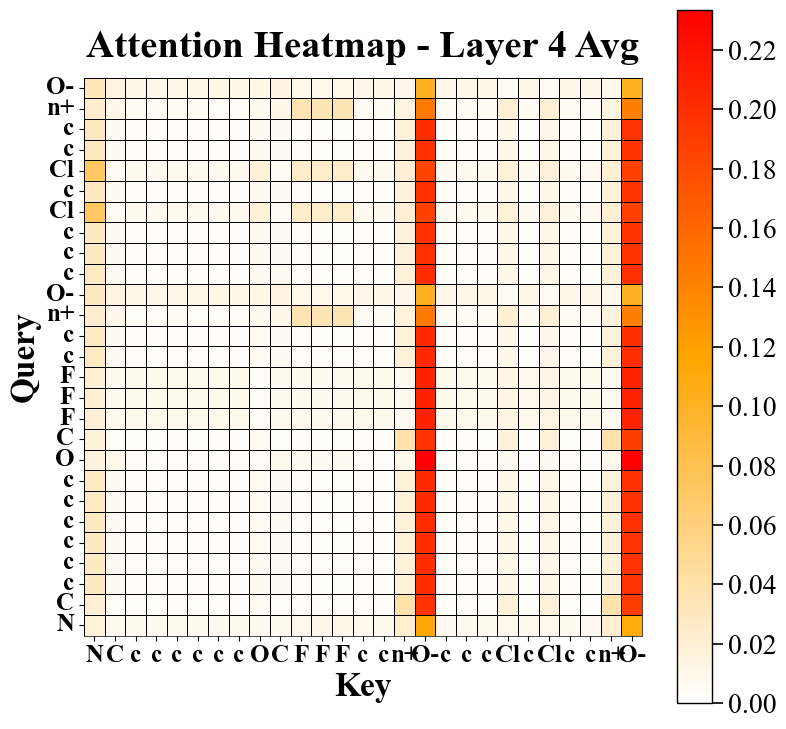

In [185]:
plt.figure(figsize=(9,9))

colors = ["white", "orange", "red"]
custom_cmap = LinearSegmentedColormap.from_list("white_orange_red", colors)

vmin_value = 0.0   
vmax_value = 0.2335   

ax = sns.heatmap(layer_4_avg_atom, 
                 xticklabels=chemical_atoms, 
                 yticklabels=chemical_atoms, 
                 cmap=custom_cmap, 
                 vmin=vmin_value, 
                 vmax=vmax_value, 
                 linewidths=0.5, 
                 linecolor='black', 
                 square=True 
                )

plt.xlabel("Key", fontsize=24, fontweight='bold')
plt.ylabel("Query", fontsize=24, fontweight='bold')

plt.title("Attention Heatmap - Layer 4 Avg", fontsize=28, pad=15, fontweight='bold')
plt.xticks(rotation=0,fontsize=18, weight='bold')
plt.yticks(rotation=0,fontsize=18, weight='bold')

ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)      
    spine.set_color('black')    

cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)       
cbar.outline.set_linewidth(1.0)      
cbar.outline.set_edgecolor('black')  

major_ticks = [0.00, 0.02, 0.04, 0.06, 0.08,0.10,0.12,0.14,0.16,0.18,0.20,0.22]
cbar.set_ticks(major_ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in major_ticks])

cbar.ax.tick_params(
    which='major',
    length=8,      
    width=1.2,     
    direction='out',
    color='black',
    labelsize=20 
)

plt.savefig(r"E:\Projects\Mycobacterium tuberculosis\07-Self-Attention Visualization on SMILES\layer_4_avg.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [171]:
attn_weights_5 = all_attn_weights[5].cpu()
attn_weights_5.shape

torch.Size([1, 8, 52, 52])

In [172]:
layer_5_head_0 = attn_weights_5[0, 0].numpy()  # head 0
print(layer_5_head_0)
print(len(layer_5_head_0))
layer_5_head_0_atom = np.round(layer_5_head_0[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_0_atom.shape)
print(len(layer_5_head_0_atom))
print(np.max(layer_5_head_0_atom))

[[2.3358381e-04 6.5356307e-06 6.9849157e-05 ... 3.0085930e-05
  4.9678472e-01 1.1417196e-05]
 [9.5800040e-03 7.6267970e-05 2.6620770e-04 ... 1.9766144e-03
  4.3503609e-01 9.6156116e-05]
 [1.4332241e-02 6.9097179e-04 4.0740208e-03 ... 6.6689041e-04
  4.3340153e-01 1.3608715e-03]
 ...
 [3.2599229e-02 2.9169649e-04 7.9918408e-04 ... 1.1729088e-02
  1.7131370e-01 5.0198782e-04]
 [1.2853937e-04 2.3251343e-07 3.3547440e-06 ... 3.8243202e-06
  4.8182508e-01 7.1283444e-07]
 [5.8509060e-04 1.7679648e-06 2.3987557e-05 ... 2.0842677e-05
  4.9034122e-01 3.3318017e-06]]
52
(27, 27)
27
0.51


In [173]:
layer_5_head_1 = attn_weights_5[0, 1].numpy()  # head 0
print(layer_5_head_1)
print(len(layer_5_head_1))
layer_5_head_1_atom = np.round(layer_5_head_1[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_1_atom.shape)
print(len(layer_5_head_1_atom))
print(np.max(layer_5_head_1_atom))

[[1.3134026e-04 1.2732764e-04 1.1110099e-04 ... 1.8078103e-04
  4.8169219e-01 7.6253215e-05]
 [1.4147047e-02 5.4304558e-03 2.7186405e-03 ... 3.6957378e-03
  1.5880505e-02 1.1915639e-03]
 [1.9393867e-02 8.2395338e-03 5.2448516e-03 ... 5.1472383e-03
  1.9528224e-01 4.0728147e-03]
 ...
 [3.1225241e-03 2.2170588e-03 3.2431961e-04 ... 1.4422743e-03
  3.9215531e-04 1.9704556e-04]
 [1.4155438e-03 1.2566932e-03 1.9528581e-03 ... 1.4746768e-03
  4.2048794e-01 3.6129256e-04]
 [5.0073168e-03 1.3659097e-03 7.4919988e-04 ... 5.6958979e-04
  2.2542611e-01 3.4982947e-04]]
52
(27, 27)
27
0.5


In [174]:
layer_5_head_2 = attn_weights_5[0, 2].numpy()  # head 0
print(layer_5_head_2)
print(len(layer_5_head_2))
layer_5_head_2_atom = np.round(layer_5_head_2[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_2_atom.shape)
print(len(layer_5_head_2_atom))
print(np.max(layer_5_head_2_atom))

[[0.00290014 0.0622959  0.00441926 ... 0.13654909 0.03495079 0.01870957]
 [0.00069549 0.00190652 0.02187181 ... 0.00486892 0.43517023 0.0029769 ]
 [0.00539251 0.01801806 0.01589876 ... 0.02748471 0.21529989 0.01772599]
 ...
 [0.00131919 0.00118117 0.13042939 ... 0.00177965 0.36167276 0.00422598]
 [0.00063806 0.00243124 0.01133929 ... 0.0031165  0.31880355 0.00491099]
 [0.00259658 0.03096293 0.00480579 ... 0.08704606 0.1519467  0.01902965]]
52
(27, 27)
27
0.5


In [175]:
layer_5_head_3 = attn_weights_5[0, 3].numpy()  # head 0
print(layer_5_head_3)
print(len(layer_5_head_3))
layer_5_head_3_atom = np.round(layer_5_head_3[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_3_atom.shape)
print(len(layer_5_head_3_atom))
print(np.max(layer_5_head_3_atom))

[[9.4401027e-04 1.7567944e-04 2.9377243e-04 ... 9.7810838e-04
  4.6475503e-01 5.1796285e-04]
 [1.6139869e-03 6.8800064e-04 1.5977694e-03 ... 1.9302686e-03
  4.4564781e-01 8.0864603e-04]
 [1.4167352e-03 2.3109192e-04 6.0054573e-04 ... 2.1749861e-03
  3.2729524e-01 9.0816565e-04]
 ...
 [1.6600392e-03 1.1954413e-03 2.4648621e-03 ... 2.9412678e-03
  4.0281332e-01 1.6433200e-03]
 [1.1568322e-02 1.9651905e-03 7.9782261e-03 ... 7.9616131e-03
  2.0543809e-01 8.2215322e-03]
 [1.3154072e-03 5.8010541e-04 3.4623264e-04 ... 2.9902873e-03
  3.7559155e-01 8.6498488e-04]]
52
(27, 27)
27
0.49


In [177]:
layer_5_head_4 = attn_weights_5[0, 4].numpy()  # head 0
print(layer_5_head_4)
print(len(layer_5_head_4))
layer_5_head_4_atom = np.round(layer_5_head_4[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_4_atom.shape)
print(len(layer_5_head_4_atom))
print(np.max(layer_5_head_4_atom))

[[7.3094354e-03 7.3576860e-02 6.0932676e-04 ... 6.2496908e-02
  1.1682460e-03 1.4332131e-02]
 [2.8072527e-04 4.8633321e-04 1.2780656e-05 ... 1.7852979e-04
  2.9230351e-04 4.3600703e-05]
 [5.1872853e-02 5.2964780e-02 8.3473942e-04 ... 2.8180774e-02
  2.5855100e-03 9.5740873e-03]
 ...
 [2.6724802e-03 3.4846161e-03 3.7510821e-04 ... 1.9720974e-03
  1.3811118e-03 7.1781228e-04]
 [2.6763991e-02 3.2059897e-02 2.2698992e-03 ... 1.0314605e-02
  1.0903551e-02 1.0166955e-02]
 [3.6885674e-04 1.3454892e-03 4.3439063e-06 ... 3.0150361e-04
  1.7446505e-04 5.9211514e-05]]
52
(27, 27)
27
0.5


In [178]:
layer_5_head_5 = attn_weights_5[0, 5].numpy()  # head 0
print(layer_5_head_5)
print(len(layer_5_head_5))
layer_5_head_5_atom = np.round(layer_5_head_5[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_5_atom.shape)
print(len(layer_5_head_5_atom))
print(np.max(layer_5_head_5_atom))

[[0.00139631 0.00149835 0.05045616 ... 0.19661452 0.13170911 0.00183522]
 [0.00290358 0.01947104 0.2222125  ... 0.22795884 0.01909149 0.05583268]
 [0.00244598 0.01486879 0.20281774 ... 0.24801944 0.03880629 0.03734379]
 ...
 [0.00889518 0.02625197 0.26227355 ... 0.08463439 0.01867436 0.11768577]
 [0.00973778 0.01332661 0.11726604 ... 0.07067715 0.01969585 0.02525786]
 [0.00209074 0.00558676 0.30978316 ... 0.17924294 0.0483465  0.0140274 ]]
52
(27, 27)
27
0.35


In [179]:
layer_5_head_6 = attn_weights_5[0, 6].numpy()  # head 0
print(layer_5_head_6)
print(len(layer_5_head_6))
layer_5_head_6_atom = np.round(layer_5_head_6[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_6_atom.shape)
print(len(layer_5_head_6_atom))
print(np.max(layer_5_head_6_atom))

[[6.59368513e-03 1.19209262e-02 4.58706915e-02 ... 7.00628757e-03
  5.47324903e-02 6.71989936e-03]
 [1.66125353e-02 7.55196996e-03 1.47284325e-02 ... 3.21876607e-03
  3.91454116e-04 4.57852706e-03]
 [2.87310965e-02 2.50339205e-03 6.97054388e-03 ... 1.11024012e-03
  5.14466374e-04 5.54256700e-03]
 ...
 [3.00661959e-02 6.17222162e-03 1.04787191e-02 ... 2.57281074e-03
  6.58670469e-05 7.15935510e-03]
 [7.41375331e-03 2.64075175e-02 4.03832532e-02 ... 1.73303206e-02
  6.00307074e-04 2.70690788e-02]
 [1.10340435e-02 5.07921819e-03 1.16121955e-02 ... 3.90820578e-03
  3.66324149e-02 3.47740622e-03]]
52
(27, 27)
27
0.06


In [180]:
layer_5_head_7 = attn_weights_5[0, 7].numpy()  # head 0
print(layer_5_head_7)
print(len(layer_5_head_7))
layer_5_head_7_atom = np.round(layer_5_head_7[np.ix_(atom_indices, atom_indices)],2)
print(layer_5_head_7_atom.shape)
print(len(layer_5_head_7_atom))
print(np.max(layer_5_head_7_atom))

[[8.22300208e-05 4.16877839e-08 2.24451753e-07 ... 2.67854858e-07
  1.04035258e-04 1.85385701e-07]
 [3.07326991e-05 2.35142235e-08 1.31327602e-06 ... 1.36686708e-07
  5.29348198e-03 2.04237551e-07]
 [1.19847013e-04 3.21848361e-08 3.46792604e-07 ... 5.51051791e-08
  1.01118232e-03 2.26031432e-07]
 ...
 [8.82291642e-05 1.53428789e-06 3.12593038e-05 ... 4.51237520e-06
  2.54324470e-02 8.82324093e-06]
 [1.27199211e-03 1.00740235e-05 3.96844916e-05 ... 2.27722885e-05
  6.76869694e-03 2.37090808e-05]
 [2.70198689e-06 6.02213210e-11 1.42399714e-09 ... 4.71685857e-10
  2.73463684e-05 6.29254926e-10]]
52
(27, 27)
27
0.09


In [181]:
layer_5_avg = attn_weights_5.mean(dim=1).numpy().squeeze(0)
print(layer_5_avg)
print(layer_5_avg.shape)
layer_5_avg_atom = layer_5_avg[np.ix_(atom_indices, atom_indices)]
print(layer_5_avg_atom.shape)
print(len(layer_5_avg_atom))
print(np.max(layer_5_avg_atom))
layer_5_avg_df = pd.DataFrame(layer_5_avg_atom, index=chemical_atoms, columns=chemical_atoms)
layer_5_avg_df.to_csv('layer_5_avg_weights.csv', index=True)

[[0.00244884 0.0187002  0.0127288  ... 0.05048201 0.20823707 0.00527533]
 [0.00573301 0.00445133 0.03292618 ... 0.03047848 0.16960043 0.00819103]
 [0.01546314 0.01218958 0.02955519 ... 0.03909804 0.15177456 0.00956606]
 ...
 [0.01005288 0.00509946 0.05089705 ... 0.01338451 0.12271821 0.01651751]
 [0.00736725 0.00968218 0.02265408 ... 0.01386268 0.1830654  0.00950152]
 [0.00287509 0.00561527 0.04091562 ... 0.03425993 0.16606079 0.00472648]]
(52, 52)
(27, 27)
27
0.2373133


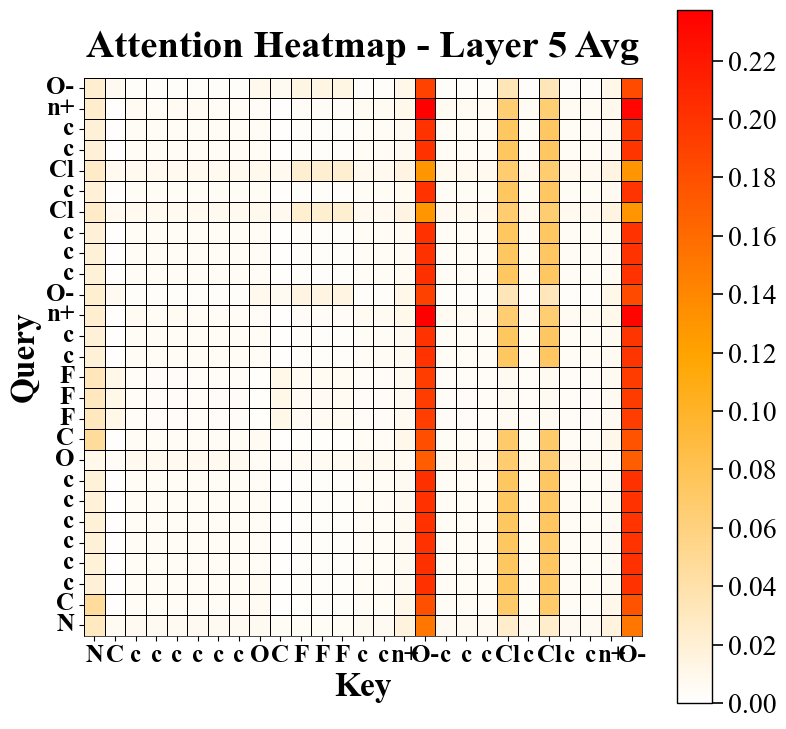

In [184]:
plt.figure(figsize=(9,9))

colors = ["white", "orange", "red"]
custom_cmap = LinearSegmentedColormap.from_list("white_orange_red", colors)

vmin_value = 0.0   
vmax_value = 0.2373  

ax = sns.heatmap(layer_5_avg_atom, 
                 xticklabels=chemical_atoms, 
                 yticklabels=chemical_atoms, 
                 cmap=custom_cmap, 
                 vmin=vmin_value, 
                 vmax=vmax_value, 
                 linewidths=0.5, 
                 linecolor='black', 
                 square=True 
                ) 

plt.xlabel("Key", fontsize=24, fontweight='bold')
plt.ylabel("Query", fontsize=24, fontweight='bold')

plt.title("Attention Heatmap - Layer 5 Avg", fontsize=28, pad=15, fontweight='bold')
plt.xticks(rotation=0,fontsize=18, weight='bold')
plt.yticks(rotation=0,fontsize=18, weight='bold')

ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)      
    spine.set_color('black')    


cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)       
cbar.outline.set_linewidth(1.0)      
cbar.outline.set_edgecolor('black')  


major_ticks = [0.00, 0.02, 0.04, 0.06, 0.08,0.10,0.12,0.14,0.16,0.18,0.20,0.22]
cbar.set_ticks(major_ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in major_ticks])

cbar.ax.tick_params(
    which='major',
    length=8,      
    width=1.2,     
    direction='out',
    color='black',
    labelsize=20 
)

plt.savefig(r"E:\Projects\Mycobacterium tuberculosis\07-Self-Attention Visualization on SMILES\layer_5_avg.pdf", format='pdf', bbox_inches='tight')

plt.show()